# Práctico 2 — Curación de datos: versión alternativa

> **Nota sobre esta notebook.** El repositorio ya tiene `02_curacion_de_datos_e_integracion.ipynb`, que resuelve la consigna completa. Esta es una segunda pasada, hecha de forma independiente, que llega a las mismas conclusiones centrales por otros caminos y agrega cuatro cosas que la otra no cubre: un experimento medido para elegir la estrategia de imputación (§3.4), recuperación de valores despejando identidades en vez de imputarlos (§3.3, §4.3), un análisis de la dimensión temporal del panel (§10), y un bloque de verificación automática (§12). Sus salidas van a archivos con nombre propio (`empresas_mario.parquet`) y no reemplazan las de la notebook principal.

**Mentoría M09 — El impacto de la IA en la fuerza laboral**

Dataset: [diplodatos-ai-impact-workforce](https://github.com/carolinapepe/diplodatos-ai-impact-workforce)

---

## Qué hace esta notebook

El Práctico 1 exploró el dataset y dejó dos hipótesis planteadas. Esta notebook prepara los datos para poder responderlas, y lo hace en un orden que no es arbitrario:

| Bloque | Contenido | Por qué va acá |
|---|---|---|
| **1** | Integridad estructural | Antes de limpiar hay que saber qué es una fila |
| **2** | Auditoría de construcción de variables | Descubrir qué variables son derivadas *antes* de imputarlas o modelarlas |
| **3** | Valores faltantes: diagnóstico y estrategia | Buena parte se recupera exacto gracias al bloque 2 |
| **4** | Valores atípicos | Genera faltantes nuevos, por eso va antes de imputar |
| **5** | Aplicación de la imputación | Resuelve de una vez los faltantes originales y los del bloque 4 |
| **6** | Integración de los tres archivos | Una vez que `df1` está limpio |
| **7** | Variables derivadas (*feature engineering*) | Resuelve las limitaciones que el TP1 dejó anotadas |
| **8** | Codificación de categóricas | |
| **9** | Datasets finales | |
| **10** | Análisis temporal del panel | Qué ofrece la dimensión que el análisis por empresa deja afuera |
| **11** | Selección de variables | Inclusiones y exclusiones justificadas |
| **12** | Verificación | Chequeos automáticos de que todo lo anterior hizo lo que dice |
| **13** | Conclusiones y puente al TP3 | |

## Resumen de decisiones (para leer antes que el código)

1. **Unidad de análisis:** entregamos **dos** datasets — el panel curado (una fila por encuesta) y la tabla agregada por empresa. El TP1 §2.4 justifica trabajar por empresa, pero conservar el panel deja abierta la línea temporal.
2. **`ai_industry_summary.csv` no se integra** como variables predictoras: verificamos que es 100% derivado de `ai_company_adoption.csv`, así que usarlo sería *leakage*. Lo recalculamos nosotros desde el dataset ya limpio, solo para uso descriptivo.
3. **Los faltantes se tratan en cascada**, no con una única estrategia: primero recuperación exacta, después imputación multivariada. La elección está respaldada por un experimento medido, no por costumbre.
4. **Los atípicos se tratan con tres reglas distintas** según el tipo de variable. Mostramos explícitamente por qué la receta estándar (IQR global) es incorrecta acá.
5. **Las variables redundantes se conservan pero quedan marcadas**, con una tabla de dependencias y una lista sugerida de columnas para modelar que las excluye por defecto.

In [1]:
# ============================================================
# Librerias
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.experimental import enable_iterative_imputer   # necesario para habilitar IterativeImputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

print("Librerias cargadas.")

Librerias cargadas.


In [2]:
# ============================================================
# Carga de los tres archivos
# ------------------------------------------------------------
# Si la notebook corre dentro del repo (notebooks/), lee de ../data/raw/.
# Si corre suelta (por ejemplo en Colab sin clonar), los baja del repo.
# ============================================================
from pathlib import Path

RAW_LOCAL  = Path("../data/raw")
RAW_REMOTO = "https://raw.githubusercontent.com/Franncippi/Proyecto-mentoria-M09/main/data/raw/"

def ruta(nombre):
    local = RAW_LOCAL / nombre
    return local if local.exists() else RAW_REMOTO + nombre

print("origen de los datos:", "local (../data/raw/)" if (RAW_LOCAL / "ai_company_adoption.csv").exists()
      else "remoto (GitHub)")

df1 = pd.read_csv(ruta("ai_company_adoption.csv"))   # encuestas trimestrales por empresa
df2 = pd.read_csv(ruta("ai_industry_summary.csv"))   # resumen por industria
df3 = pd.read_csv(ruta("country_ai_index.csv"))      # indicadores por pais

for nombre, d in [("df1", df1), ("df2", df2), ("df3", df3)]:
    print(f"{nombre}: {d.shape[0]:>7,} filas x {d.shape[1]:>2} columnas")

origen de los datos: local (../data/raw/)


df1: 150,025 filas x 43 columnas
df2:       9 filas x  8 columnas
df3:      30 filas x  8 columnas


---
# 1. Integridad estructural

> **Consigna (parte de):** integrar los archivos disponibles en una única estructura de análisis coherente.

Antes de limpiar nada hay que contestar una pregunta previa: **¿qué representa una fila?** Si la respuesta está mal, todo lo que venga después (imputar, detectar atípicos, calcular correlaciones) está mal.

## 1.1 `df1` no es una tabla de empresas, es un panel

Un **panel** (o *datos longitudinales*) es una tabla donde la misma unidad aparece varias veces, medida en momentos distintos. Acá cada empresa fue encuestada trimestre a trimestre.

Esto importa por dos razones concretas:

- Las filas **no son independientes entre sí**. 15 filas de `COMP-00001` son la misma empresa. Cualquier técnica que las trate como 15 observaciones distintas sobreestima la cantidad de información disponible.
- Habilita una forma de imputación que no existiría en una tabla plana: si a una empresa le falta un dato en un trimestre, lo podemos buscar en sus otros trimestres.

In [3]:
# ¿Cuantas empresas hay y cuantas veces aparece cada una?
print("filas totales    :", f"{len(df1):,}")
print("empresas distintas:", f"{df1['company_id'].nunique():,}")
print("\nCantidad de trimestres observados por empresa:")
print(df1.groupby("company_id").size().value_counts().sort_index().to_string())

print("\nPeriodo cubierto:", int(df1.survey_year.min()), "-", int(df1.survey_year.max()),
      "| trimestres:", sorted(df1.quarter.dropna().unique()))

filas totales    : 150,025
empresas distintas: 10,025

Cantidad de trimestres observados por empresa:
1       25
10       5
11      31
12     130
13     583
14    1871
15    3804
16    3576

Periodo cubierto: 2023 - 2026 | trimestres: ['Q1', 'Q2', 'Q3', 'Q4']


In [4]:
# Chequeo de duplicados a los dos niveles que importan
print("filas identicas completas          :", df1.duplicated().sum())
print("response_id repetidos              :", df1.response_id.duplicated().sum())
print("combinacion (empresa, anio, trim.) :", df1.duplicated(subset=["company_id","survey_year","quarter"]).sum())

filas identicas completas          : 0
response_id repetidos              : 0
combinacion (empresa, anio, trim.) : 0


**Lectura:** 10.025 identificadores de empresa, con 15 o 16 observaciones cada uno en la enorme mayoría de los casos (4 años × 4 trimestres = 16 posibles). Cero duplicados en cualquiera de los tres criterios: no hay filas repetidas ni encuestas cargadas dos veces.

Pero 10.025 es un número raro. Los identificadores deberían ir de `COMP-00001` a `COMP-10000`.

## 1.2 Hay 25 registros basura plantados

El grupo de empresas con **una sola** observación (25 casos) es sospechoso: si el panel es trimestral y todas las demás tienen 15 o 16 filas, una empresa con una sola encuesta rompe el patrón.

In [5]:
# ¿Los identificadores siguen todos el mismo formato COMP-#####?
formato_ok = df1.company_id.str.match(r"^COMP-\d{5}$")
print("identificadores con formato esperado :", formato_ok.sum())
print("identificadores con formato distinto :", (~formato_ok).sum())
print("\nEjemplos de los que no siguen el formato:")
print(df1.loc[~formato_ok, "company_id"].unique()[:10])

identificadores con formato esperado : 150000
identificadores con formato distinto : 25

Ejemplos de los que no siguen el formato:
<ArrowStringArray>
['COMP-FAKE-001', 'COMP-FAKE-002', 'COMP-FAKE-003', 'COMP-FAKE-004', 'COMP-FAKE-005', 'COMP-FAKE-006', 'COMP-FAKE-007', 'COMP-FAKE-008', 'COMP-FAKE-009', 'COMP-FAKE-010']
Length: 10, dtype: str


In [6]:
# Miramos esas filas: ¿son datos plausibles?
fake = df1[~formato_ok]
print(f"{len(fake)} filas\n")
print(fake[["company_id","num_employees","annual_revenue_usd_millions",
            "employee_satisfaction_score","productivity_change_percent",
            "ai_investment_per_employee"]].head(10).round(2).to_string(index=False))

25 filas

   company_id  num_employees  annual_revenue_usd_millions  employee_satisfaction_score  productivity_change_percent  ai_investment_per_employee
COMP-FAKE-001          597.0                        73.15                         4.60                        10.62                    11400.55
COMP-FAKE-002          192.0                     28901.06                         7.49                        23.41                   296551.40
COMP-FAKE-003           62.0                        17.62                         5.79                        20.77                   620069.03
COMP-FAKE-004          555.0                       291.56                         5.07                         6.60                    50656.27
COMP-FAKE-005        10811.0                      7013.93                         5.14                        10.50                    46285.82
COMP-FAKE-006           12.0                         2.78                         6.32                        11.46           

**Lectura:** son 25 filas con identificador `COMP-FAKE-001` … `COMP-FAKE-025`, una observación cada una, y valores que violan la lógica del dominio:

- empresas de 16 y 258 empleados con facturación anual de USD 29.000 y 27.600 **millones**;
- `employee_satisfaction_score` de 13,8 y 15,3 en una escala que va de 1 a 10;
- `productivity_change_percent` de −45,8% y +56,7%.

No son outliers a discutir: son registros que **no pertenecen al dataset**. Se eliminan y se documenta la eliminación.

Vale la pena notar el criterio: no los detectamos por sus valores extremos, sino por una **inconsistencia estructural** (formato de identificador y cantidad de observaciones). Es un chequeo mucho más barato y más seguro que buscar valores raros de a una columna por vez.

In [7]:
# ============================================================
# LIMPIEZA 1: eliminacion de registros basura
# ============================================================
registro = []   # iremos anotando cada decision para el resumen final

n_antes = len(df1)
df = df1[formato_ok].copy().reset_index(drop=True)
n_despues = len(df)

registro.append({"paso":"1.2 registros basura", "accion":"eliminar filas COMP-FAKE-*",
                 "filas_afectadas": n_antes-n_despues, "valores_afectados": np.nan})

print(f"filas antes   : {n_antes:,}")
print(f"filas despues : {n_despues:,}   (-{n_antes-n_despues})")
print(f"empresas      : {df.company_id.nunique():,}")

filas antes   : 150,025
filas despues : 150,000   (-25)
empresas      : 10,000


---
# 2. Auditoría de construcción de variables

> **Consigna:** *…prestando especial atención a aquellas variables cuyo significado o forma de construcción no resulte del todo evidente, y discutiendo qué riesgos implica incluirlas sin entenderlas del todo.*

Este bloque va **antes** de imputar y de tratar atípicos, y el orden es deliberado. Si una variable resulta ser una función exacta de otras, entonces:

- imputarla con un algoritmo es un desperdicio: se despeja de la fórmula, sin error;
- usarla en un modelo junto a sus componentes es un error metodológico;
- y su relación con esos componentes no es un hallazgo, es una identidad.

El repositorio no incluye un diccionario de datos, así que lo que sigue es **ingeniería inversa**: le preguntamos a los datos cómo fueron construidos.

## 2.1 ¿Qué variables son constantes dentro de cada empresa?

Primer chequeo: para cada columna, contamos cuántos valores distintos toma dentro de una misma empresa a lo largo de sus trimestres. Una columna que toma **siempre un solo valor** describe a la empresa, no a la encuesta.

In [8]:
cols = [c for c in df.columns if c not in ["response_id", "company_id"]]
filas = []
for c in cols:
    nu = df.groupby("company_id")[c].nunique(dropna=True)
    filas.append({"variable": c,
                  "max_valores_en_una_empresa": nu.max(),
                  "empresas_con_mas_de_1": int((nu > 1).sum()),
                  "%_empresas_con_mas_de_1": round((nu > 1).mean()*100, 1)})

constancia = pd.DataFrame(filas).sort_values("%_empresas_con_mas_de_1")
print(constancia.head(12).to_string(index=False))

                   variable  max_valores_en_una_empresa  empresas_con_mas_de_1  %_empresas_con_mas_de_1
                     region                           1                      0                      0.0
                    country                           1                      0                      0.0
               company_size                           1                      0                      0.0
                   industry                           1                      0                      0.0
              num_employees                           1                      0                      0.0
      company_founding_year                           1                      0                      0.0
annual_revenue_usd_millions                           3                    299                      3.0
          company_age_group                           2                   2759                     27.6
          ai_adoption_stage                           4         

In [9]:
CONSTANTES_POR_EMPRESA = constancia.loc[constancia["%_empresas_con_mas_de_1"] == 0, "variable"].tolist()
print("Variables perfectamente constantes dentro de cada empresa:")
for c in CONSTANTES_POR_EMPRESA:
    print("  -", c)

Variables perfectamente constantes dentro de cada empresa:
  - region
  - country
  - company_size
  - industry
  - num_employees
  - company_founding_year


**Lectura:** seis variables son constantes dentro de cada empresa, **sin una sola excepción en 10.000 empresas**: `country`, `region`, `industry`, `company_size`, `num_employees`, `company_founding_year`.

Tiene sentido — son atributos de la empresa, no de la encuesta. Pero la consecuencia práctica es fuerte: **cualquier valor faltante en estas seis columnas se puede recuperar de forma exacta** mirando otro trimestre de la misma empresa. No hay que imputar (estimar un valor plausible), hay que *recuperar* (traer el valor verdadero).

Dos casos intermedios que conviene mirar:

- `annual_revenue_usd_millions`: constante en el 97% de las empresas. El 3% restante no es variación real, son valores contaminados — lo retomamos en el bloque 4.
- `company_age_group`: cambia en el 27,6% de las empresas, lo cual es esperable: si una empresa cumple 16 años en medio del período, pasa de un grupo etario al siguiente.

## 2.2 Cuatro variables son funciones exactas de otras

Ahora buscamos **identidades**: relaciones que se cumplen exactamente, fila por fila, no "aproximadamente" ni "con alta correlación".

La diferencia importa. Dos variables pueden correlacionar 0,95 y ser cosas distintas. Si la relación se cumple con residuo cero en 150.000 filas, no es una asociación: una variable **es** la otra, escrita de otra forma.

In [10]:
# --- Identidad 1: company_age = survey_year - company_founding_year
res1 = (df.survey_year - df.company_founding_year - df.company_age).dropna()
print("Identidad 1 -> company_age = survey_year - company_founding_year")
print(f"   filas evaluadas: {len(res1):,} | residuos distintos de cero: {(res1 != 0).sum()}")

Identidad 1 -> company_age = survey_year - company_founding_year
   filas evaluadas: 150,000 | residuos distintos de cero: 0


In [11]:
# --- Identidad 2: company_age_group son bins de company_age
bins_edad = pd.cut(df.company_age, [-0.1, 5, 15, 30, 999],
                   labels=["0-5 years", "6-15 years", "16-30 years", "30+ years"])
tabla = pd.crosstab(bins_edad, df.company_age_group)
print("Identidad 2 -> company_age_group = bins(company_age)")
print(tabla.to_string())
print("\n   (si la tabla es diagonal, la correspondencia es perfecta)")

Identidad 2 -> company_age_group = bins(company_age)
company_age_group  0-5 years  16-30 years  30+ years  6-15 years
company_age                                                     
0-5 years              15372            0          0           0
6-15 years                 0            0          0       45992
16-30 years                0        68383          0           0
30+ years                  0            0      20253           0

   (si la tabla es diagonal, la correspondencia es perfecta)


In [12]:
# --- Identidad 3: company_size son bins de num_employees
print("Identidad 3 -> company_size = bins(num_employees)")
print(df.groupby("company_size")["num_employees"].agg(["count","min","max"]).to_string())
print("\n   (si los rangos no se solapan, company_size no agrega informacion)")

Identidad 3 -> company_size = bins(num_employees)
              count     min      max
company_size                        
Enterprise    28970  1010.0  19970.0
SME           62934   100.0    999.0
Startup       55846    10.0     99.0

   (si los rangos no se solapan, company_size no agrega informacion)


Las tres primeras son inocuas y bastante evidentes. La cuarta no lo es.

### `ai_maturity_score`: el caso interesante

Es la variable con el nombre más sugerente del dataset — "puntaje de madurez en IA" suena a una medición sustantiva, y en el TP1 la usamos como si lo fuera. En el análisis por industria correlacionaba 0,82 con el presupuesto de IA y lo interpretamos como un hallazgo.

Si miramos con qué correlaciona, aparece un patrón sospechoso: correlaciona fuerte con **varias** variables a la vez, todas del mismo grupo temático.

In [13]:
candidatas = ["ai_adoption_rate","ai_budget_percentage","ai_projects_active","ai_training_hours",
              "num_ai_tools_used","years_using_ai","task_automation_rate","ai_investment_per_employee"]
print("Correlacion de ai_maturity_score con sus candidatas a componentes:")
print(df[["ai_maturity_score"]+candidatas].corr()["ai_maturity_score"].drop("ai_maturity_score")
        .sort_values(ascending=False).round(3).to_string())

Correlacion de ai_maturity_score con sus candidatas a componentes:
ai_budget_percentage          0.819
ai_projects_active            0.804
ai_adoption_rate              0.792
ai_training_hours             0.775
task_automation_rate          0.590
num_ai_tools_used             0.454
ai_investment_per_employee    0.275
years_using_ai                0.155


Correlaciones de 0,82 / 0,80 / 0,78 con tres variables distintas es exactamente lo que se ve cuando una variable es un **promedio** de esas tres. Lo probamos con una regresión lineal: si `ai_maturity_score` es una combinación lineal de sus componentes, el R² tiene que dar **exactamente 1**.

> **R²** (coeficiente de determinación): mide qué proporción de la variación de una variable queda explicada por otras. Va de 0 a 1. Un R² de 0,95 es "muy buena predicción". Un R² de **1,0000 con residuo cero** no es una predicción: es una identidad algebraica.

In [14]:
# Ajustamos una regresion lineal por minimos cuadrados. Excluimos las filas con
# ai_training_hours fuera de rango (las trataremos en el bloque 4) para que no ensucien el ajuste.
comp = ["ai_budget_percentage","ai_projects_active","ai_training_hours"]
sub = df[["ai_maturity_score"]+comp].dropna()
sub = sub[sub.ai_training_hours.between(0, 100)]

X = np.c_[np.ones(len(sub)), sub[comp].values]
y = sub.ai_maturity_score.values
coef, *_ = np.linalg.lstsq(X, y, rcond=None)
pred = X @ coef
r2 = 1 - ((y-pred)**2).sum() / ((y-y.mean())**2).sum()

print(f"R2 = {r2:.6f}")
print(f"residuo maximo absoluto = {np.abs(y-pred).max():.8f}\n")
print("Coeficientes estimados y su lectura:")
print(f"  intercepto            = {coef[0]:.6f}")
for nombre, c in zip(comp, coef[1:]):
    print(f"  {nombre:22s} = {c:.6f}   ->  1 / {1/c:,.0f}")

R2 = 0.999995
residuo maximo absoluto = 0.00058443

Coeficientes estimados y su lectura:
  intercepto            = 0.000004
  ai_budget_percentage   = 0.013333   ->  1 / 75
  ai_projects_active     = 0.016667   ->  1 / 60
  ai_training_hours      = 0.004167   ->  1 / 240


**Lectura.** El R² da 0,999995 y el residuo máximo es 0,0006. Esa diferencia con 1 exacto **no** es ruido del fenómeno: es el redondeo de `ai_maturity_score` a tres decimales. Si el valor viniera con toda su precisión, el ajuste sería exacto.

Y los coeficientes no son números arbitrarios: 1/75, 1/60 y 1/240. Reescritos, revelan la fórmula original.

$$\texttt{ai\_maturity\_score} \;=\; \frac{1}{3}\left(\frac{\texttt{ai\_budget\_percentage}}{25} + \frac{\texttt{ai\_projects\_active}}{20} + \frac{\texttt{ai\_training\_hours}}{80}\right)$$

Es un **índice compuesto**: cada componente se escala a 0–1 dividiéndolo por su valor máximo posible (25% de presupuesto, 20 proyectos, 80 horas), y después se promedian los tres con peso igual. Lo verificamos sobre todas las filas, con una tolerancia de 0,001 que absorbe el redondeo.

In [15]:
def formula_madurez(d):
    return (d.ai_budget_percentage/25 + d.ai_projects_active/20 + d.ai_training_hours/80) / 3

residuo_madurez = (df.ai_maturity_score - formula_madurez(df))
ok = residuo_madurez.abs() <= 0.001

print(f"filas evaluables            : {residuo_madurez.notna().sum():,}")
print(f"filas donde la formula da   : {ok.sum():,}  ({ok.sum()/residuo_madurez.notna().sum()*100:.2f}%)")
print(f"filas donde NO da           : {(residuo_madurez.notna() & ~ok).sum():,}")
print(f"residuo maximo entre las OK : {residuo_madurez[ok].abs().max():.6f}")

filas evaluables            : 145,525
filas donde la formula da   : 145,230  (99.80%)
filas donde NO da           : 295
residuo maximo entre las OK : 0.000583


**Lectura y consecuencias.** La fórmula se cumple con residuo cero en 145.230 de 145.525 filas evaluables. Las 295 excepciones no son ruido: son exactamente las filas donde uno de los componentes está contaminado (bloque 4).

Tres consecuencias, en orden de importancia:

1. **`ai_maturity_score` no aporta información nueva.** Todo lo que dice ya está en `ai_budget_percentage`, `ai_projects_active` y `ai_training_hours`.
2. **Usarla junto a sus componentes en un modelo genera colinealidad perfecta.** *Colinealidad* = dos o más variables que dicen lo mismo; el modelo no puede separar el efecto de cada una y los coeficientes salen inestables, a veces con el signo cambiado. En el caso extremo (dependencia exacta como esta) el sistema directamente no tiene solución única.
3. **Las correlaciones que reportamos en el TP1 con esta variable eran circulares.** Decir "la madurez en IA se asocia con el presupuesto de IA (r = 0,82)" no describe el mundo: describe que el presupuesto está adentro de la fórmula de la madurez. Hay que corregir esa lectura.

Y hay un beneficio inesperado: **la fórmula se puede despejar**. Si falta `ai_budget_percentage` pero tenemos madurez, proyectos y horas, el valor se recupera exacto. Lo usamos en el bloque 3.

## 2.3 `ai_industry_summary.csv` (df2) es un resumen de df1, no una fuente externa

`df2` tiene 9 filas (una por industria) con siete columnas que empiezan con `avg_`. La pregunta es si esos promedios provienen de otra fuente —lo cual los haría información nueva— o si están calculados sobre las mismas encuestas que ya tenemos.

Lo resolvemos recalculándolos.

In [16]:
mapa = {"avg_ai_adoption_rate":"ai_adoption_rate",
        "avg_productivity_change_percent":"productivity_change_percent",
        "avg_ai_maturity_score":"ai_maturity_score",
        "avg_ai_failure_rate":"ai_failure_rate",
        "avg_jobs_displaced":"jobs_displaced",
        "avg_jobs_created":"jobs_created",
        "avg_customer_satisfaction":"customer_satisfaction"}

calc = df.groupby("industry")[list(mapa.values())].mean()
calc.columns = list(mapa.keys())
cmp_ = df2.set_index("industry").join(calc, rsuffix="_recalculado")

filas = []
for c in mapa:
    a, b = cmp_[c], cmp_[c+"_recalculado"]
    filas.append({"metrica": c, "correlacion": round(a.corr(b), 5),
                  "dif_media_absoluta": round((a-b).abs().mean(), 4),
                  "dif_relativa_%": round(((a-b).abs()/b.abs()).mean()*100, 3)})
print(pd.DataFrame(filas).to_string(index=False))

                        metrica  correlacion  dif_media_absoluta  dif_relativa_%
           avg_ai_adoption_rate      0.99990              0.0350           0.098
avg_productivity_change_percent      0.99957              0.0450           0.491
          avg_ai_maturity_score      0.99481              0.0023           0.671
            avg_ai_failure_rate      0.99998              0.0055           0.021
             avg_jobs_displaced      0.99977              0.1925           0.173
               avg_jobs_created      0.99992              0.1534           0.129
      avg_customer_satisfaction      0.99935              0.0027           0.050


**Lectura:** correlación de 0,999 a 1,000 en las siete métricas, con diferencias relativas por debajo del 0,2%. Las diferencias que quedan se explican por los 25 registros basura que nosotros ya eliminamos y que sí estaban incluidos cuando se generó `df2`.

`df2` es **redundante por construcción**. Y no es solo redundante: es peligroso.

> ***Leakage*** **(fuga de información):** ocurre cuando una variable predictora contiene, directa o indirectamente, información sobre la respuesta que se quiere predecir. El modelo aprende un atajo, muestra un rendimiento excelente en los datos de entrenamiento, y fracasa en datos nuevos.

Si mergeáramos `df2` por industria, cada empresa recibiría como variable el **promedio de su propia industria en la variable objetivo**. Para predecir `productivity_change_percent` de una empresa de Technology, el modelo tendría disponible el promedio de productividad de Technology — que incluye a esa misma empresa. Es un caso de manual.

**Decisión:** `df2` no se integra como variables predictoras. En el bloque 5 recalculamos nuestra propia tabla por industria a partir del `df1` ya curado, para uso descriptivo únicamente.

## 2.4 `country_ai_index.csv` (df3) sí es información externa

Al revés que `df2`, ninguna de las columnas de `df3` se puede calcular desde `df1`: PBI per cápita, penetración de internet, patentes de IA e investigadores por millón son datos del país, no agregados de las encuestas. Es la única fuente de contexto genuina de las tres.

Lo que hay que verificar es que la unión sea limpia.

In [17]:
paises_df1 = set(df.country.dropna().unique())
paises_df3 = set(df3.country.unique())

print(f"paises en df1: {len(paises_df1)} | paises en df3: {len(paises_df3)}")
print("en df1 y no en df3:", sorted(paises_df1 - paises_df3) or "ninguno")
print("en df3 y no en df1:", sorted(paises_df3 - paises_df1) or "ninguno")

chk = df[["country","region"]].drop_duplicates().merge(
        df3[["country","region"]], on="country", how="left", suffixes=("_df1","_df3"))
print("\npaises donde la region de df1 no coincide con la de df3:",
      (chk.region_df1 != chk.region_df3).sum())

paises en df1: 30 | paises en df3: 30
en df1 y no en df3: ninguno
en df3 y no en df1: ninguno



paises donde la region de df1 no coincide con la de df3: 0


**Lectura:** los 30 países coinciden exactamente y la columna `region` es consistente entre los dos archivos. La unión no requiere ninguna normalización de nombres.

> ⚠️ **Nota sobre el TP1.** Ahí renombramos `USA → United States` y `UK → United Kingdom`. Eso fue **solo** para que `plotly` reconociera los países en los mapas, y en la versión corregida ya se hace sobre una copia. Para el *join* hay que usar los nombres originales: si renombráramos `df3` y no `df1`, perderíamos esos dos países en la unión (unas 10.000 filas).

Una advertencia sobre qué tanto aporta: `df3` tiene 30 filas para 10.000 empresas. Al unirlo, sus cinco variables numéricas toman solo 30 valores distintos cada una. Aportan contexto, pero **no varían entre empresas de un mismo país**, así que su poder explicativo a nivel empresa es limitado por construcción.

Acá cruzamos la categoría de un trimestre contra la del trimestre siguiente, dentro de cada empresa. Si fuera un atributo real de la empresa, esperaríamos una diagonal marcada (empresas que repiten). Si es ruido generado al azar, la elección de un trimestre no dice nada sobre la del siguiente.

> ⚠️ **Cuidado con el p-valor cuando la muestra es enorme.** Con 150.000 filas, el test detecta como "significativa" cualquier desviación por mínima que sea. Un p-valor de 0,0000 no significa "la relación es fuerte", significa "la relación no es exactamente cero". Por eso, además del test, miramos el **tamaño del efecto**: la **V de Cramér** (medida de asociación entre categóricas, de 0 a 1) y la comparación directa entre la probabilidad observada de repetir categoría y la esperada por azar.

In [18]:
d = df.sort_values(["company_id","survey_year","quarter"]).copy()

def v_de_cramer(chi2, tabla):
    n = tabla.values.sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

def prob_repetir_por_azar(d, var, dentro_de=None):
    """P(repetir categoria) si en cada trimestre se sorteara al azar.
    dentro_de: si se pasa una columna (ej. 'industry'), el sorteo se hace
    con las frecuencias DE ESE GRUPO, no las globales."""
    if dentro_de is None:
        p = d[var].value_counts(normalize=True)
        return (p ** 2).sum()
    total = 0.0
    for _, g in d.groupby(dentro_de):
        p = g[var].value_counts(normalize=True)
        total += (p ** 2).sum() * len(g)
    return total / len(d)

for var in ["ai_primary_tool", "ai_use_case", "ai_adoption_stage", "data_privacy_level"]:
    d["_sig"] = d.groupby("company_id")[var].shift(-1)
    # solo los pares validos: la ultima observacion de cada empresa no tiene "trimestre siguiente"
    pares = d.dropna(subset=[var, "_sig"])
    trans = pd.crosstab(pares[var], pares["_sig"])
    chi2, p, gl, esp = stats.chi2_contingency(trans)
    p_obs      = (pares[var] == pares["_sig"]).mean()
    p_azar     = prob_repetir_por_azar(pares, var)
    p_azar_ind = prob_repetir_por_azar(pares, var, dentro_de="industry")
    print(f"--- {var} ---")
    print(f"  chi2 = {chi2:9.1f} | gl = {gl:3d} | p = {p:.4f} | V de Cramer = {v_de_cramer(chi2, trans):.4f}")
    print(f"  P(repetir) observada .................... {p_obs:.4f}")
    print(f"  P(repetir) por azar, frecuencias globales {p_azar:.4f}   -> exceso {(p_obs/p_azar-1)*100:+.1f}%")
    print(f"  P(repetir) por azar, DENTRO de industria  {p_azar_ind:.4f}   -> exceso {(p_obs/p_azar_ind-1)*100:+.1f}%\n")

--- ai_primary_tool ---
  chi2 =      68.1 | gl =  25 | p = 0.0000 | V de Cramer = 0.0100
  P(repetir) observada .................... 0.1996
  P(repetir) por azar, frecuencias globales 0.1963   -> exceso +1.7%
  P(repetir) por azar, DENTRO de industria  0.1970   -> exceso +1.4%



--- ai_use_case ---
  chi2 =   46304.4 | gl =  49 | p = 0.0000 | V de Cramer = 0.2174
  P(repetir) observada .................... 0.2499
  P(repetir) por azar, frecuencias globales 0.1603   -> exceso +55.9%
  P(repetir) por azar, DENTRO de industria  0.2463   -> exceso +1.5%

--- ai_adoption_stage ---
  chi2 =   25102.0 | gl =   9 | p = 0.0000 | V de Cramer = 0.2445
  P(repetir) observada .................... 0.6150
  P(repetir) por azar, frecuencias globales 0.4594   -> exceso +33.9%
  P(repetir) por azar, DENTRO de industria  0.4609   -> exceso +33.4%



--- data_privacy_level ---
  chi2 =     166.6 | gl =   4 | p = 0.0000 | V de Cramer = 0.0248
  P(repetir) observada .................... 0.3959
  P(repetir) por azar, frecuencias globales 0.3838   -> exceso +3.2%
  P(repetir) por azar, DENTRO de industria  0.3896   -> exceso +1.6%




**Lectura — con una trampa adentro.** El test rechaza la independencia en los cuatro casos (p ≈ 0), pero con 150.000 filas eso ya sabemos que no dice mucho. Lo que importa son las dos últimas líneas de cada bloque:

| variable | repite | por azar (global) | por azar (dentro de su industria) |
|---|---|---|---|
| `ai_primary_tool` | 0,1996 | 0,1963 → **+1,7%** | 0,1970 → **+1,4%** |
| `ai_use_case` | 0,2499 | 0,1603 → **+55,9%** | 0,2463 → **+1,5%** |
| `ai_adoption_stage` | 0,6150 | 0,4594 → **+33,9%** | 0,4609 → **+33,4%** |
| `data_privacy_level` | 0,3959 | 0,3838 → **+3,2%** | 0,3896 → **+1,6%** |

- **`ai_primary_tool`**: +1,7% sobre el azar, V de Cramér ≈ 0,01. Indistinguible del ruido. Una empresa que cambia de herramienta principal cada trimestre no es un comportamiento creíble.
- **`ai_use_case`**: contra las frecuencias globales el exceso parece enorme (**+55,9%**), y la lectura inmediata sería "acá hay inercia real". **Es un espejismo.** Como se ve en §2.6, cada industria tiene un menú acotado de cuatro casos de uso; y como la industria es constante dentro de cada empresa, repetir es más probable *por construcción*. Comparando contra el azar **dentro de su propia industria**, el exceso cae a **+1,5%**: la empresa sortea al azar dentro de su menú. **También es ruido.**
- **`ai_adoption_stage`**: +33,4% que **sobrevive** al control por industria. Persistencia real, como corresponde a una variable que describe un estado de la empresa.
- **`data_privacy_level`**: +1,6% tras el control. Ruido.

**La lección metodológica, que es lo que vale de esta sección:** la referencia contra la que se compara importa tanto como el test. Contra el azar global, `ai_use_case` parecía la variable con más estructura del grupo; contra el azar dentro del grupo correcto, no queda nada. Mirar el tamaño del efecto no alcanza — hay que mirar **contra qué** se lo está midiendo.

**Consecuencias:**

- `ai_primary_tool`, `ai_use_case`, `data_privacy_level`, `survey_source` y `data_collection_method` se conservan en el panel y se excluyen de la tabla por empresa: no hay un valor representativo que las resuma.
- **Esto debilita la Hipótesis 2 del TP1**, que proponía `ai_use_case` como predictor central con el argumento de que "el tipo de tarea automatizada importa más que el volumen de automatización". Esa variable no aporta información propia de la empresa más allá de su industria — que ya está en el modelo. Hay que reformular el mecanismo o buscar otra variable que capture la idea.


## 2.6 Otros rastros del generador

Tres verificaciones más sobre cómo fue construido el dataset. Ninguna es evidente mirando una columna aislada.

In [19]:
# --- (a) ¿Cada industria tiene un menu fijo de casos de uso? ---
menu = pd.crosstab(df.industry, df.ai_use_case)
print("Casos de uso distintos que aparecen en cada industria:")
print((menu > 0).sum(axis=1).to_string())
print(f"\n(de {df.ai_use_case.nunique()} casos de uso posibles en todo el dataset)")

Casos de uso distintos que aparecen en cada industria:
industry
Agriculture      4
Consulting       4
Education        4
Finance          4
Healthcare       4
Logistics        4
Manufacturing    4
Retail           4
Technology       4

(de 8 casos de uso posibles en todo el dataset)


In [20]:
# --- (b) ¿ai_investment_per_employee es una variable medida o una cuenta? ---
s = df.dropna(subset=["ai_investment_per_employee","ai_budget_percentage",
                      "annual_revenue_usd_millions","num_employees"])
s = s[(s.ai_investment_per_employee > 0) & (s.annual_revenue_usd_millions > 0)]

# hipotesis: presupuesto_IA = % del presupuesto x facturacion; luego se reparte por empleado
calculado = s.ai_budget_percentage/100 * s.annual_revenue_usd_millions*1e6 / s.num_employees
ratio = s.ai_investment_per_employee / calculado

print(f"ratio observado/calculado -> mediana: {ratio.median():.4f} | p25: {ratio.quantile(.25):.3f} | p75: {ratio.quantile(.75):.3f}")
print(f"filas evaluadas: {len(s):,}")

ratio observado/calculado -> mediana: 1.0000 | p25: 1.000 | p75: 1.000
filas evaluadas: 144,482


In [21]:
# --- (c) ¿Hay valores que se repiten exactamente, senal de un tope o piso del generador? ---
print("Valor mas repetido de cada variable de resultado:\n")
for c in ["cost_reduction_percent","revenue_growth_percent","productivity_change_percent",
          "ai_failure_rate","ai_adoption_rate"]:
    vc = df[c].value_counts()
    print(f"  {c:30s} valor {vc.index[0]:>8.2f} aparece {vc.iloc[0]:>6,} veces ({vc.iloc[0]/len(df)*100:.1f}%)")

Valor mas repetido de cada variable de resultado:

  cost_reduction_percent         valor     0.00 aparece 15,858 veces (10.6%)
  revenue_growth_percent         valor    -5.00 aparece  5,985 veces (4.0%)
  productivity_change_percent    valor     0.00 aparece  9,005 veces (6.0%)
  ai_failure_rate                valor    40.00 aparece  5,237 veces (3.5%)
  ai_adoption_rate               valor     0.00 aparece    879 veces (0.6%)



**Lectura de las tres.**

**(a) Cada industria tiene exactamente 4 casos de uso posibles**, de los 8 que existen en el dataset. `ai_use_case` no es una elección libre de la empresa: es un sorteo dentro del menú que le toca a su industria. Es lo que explica el falso "+55,9% de persistencia" de §2.5, y significa que la variable no aporta nada que `industry` no aporte ya.

**(b) `ai_investment_per_employee` tampoco es una medición independiente.** El ratio entre el valor observado y `(presupuesto% × facturación) / empleados` tiene mediana, p25 y p75 **todos en 1,000** sobre 144.482 filas: la variable *es* esa cuenta. Es el mismo caso que `ai_maturity_score` — una combinación de tres variables que ya tenemos, con nombre de medición. Interpretar un coeficiente sobre ella como "efecto de la inversión en IA" sería atribuirle un significado que no tiene.

**(c) Varias variables de resultado están truncadas por el generador.** `cost_reduction_percent` tiene el valor exactamente `0,00` en el **10,6%** de las filas, `productivity_change_percent` en el 6,0%, y `ai_failure_rate` se amontona en su máximo de 40,00. No son distribuciones continuas: hay recortes en cero y topes duros. Eso explica buena parte de la curtosis extrema que el TP1 había reportado, y rompe los supuestos de cualquier modelo que asuma continuidad.

Ninguna de las tres invalida el análisis, pero las tres cambian cómo hay que leer los resultados.


## 2.7 Tabla de dependencias

Resumen de todo lo encontrado en este bloque. Esta tabla es la que responde directamente el pedido de la consigna sobre variables cuya construcción no es evidente.

In [22]:
dependencias = pd.DataFrame([
 ("company_age","derivada exacta","survey_year - company_founding_year",
  "Redundante. Conservar una sola de las tres (edad, anio de fundacion, anio de encuesta)."),
 ("company_age_group","derivada exacta","bins de company_age",
  "Redundante y ademas pierde informacion al discretizar."),
 ("company_size","derivada exacta","bins de num_employees",
  "Redundante. Util como variable de corte para graficos, no como predictor junto a num_employees."),
 ("ai_maturity_score","derivada exacta","(budget/25 + projects/20 + training/80)/3",
  "COLINEALIDAD PERFECTA con sus 3 componentes. No usar junto a ellos. Sus correlaciones con ellos son circulares."),
 ("ai_investment_per_employee","derivada (con ruido)","(ai_budget_percentage x annual_revenue) / num_employees",
  "Ratio observado/calculado con mediana 1,0000 (§2.6). No es una medicion independiente."),
 ("cost_reduction_percent","truncada","piso artificial en 0,00 (>10% de las filas)",
  "Acumulacion en un punto: rompe supuestos de continuidad y explica parte de su curtosis."),
 ("ai_use_case","determinada por la industria","cada industria tiene un menu fijo de 4 casos",
  "No aporta informacion propia de la empresa mas alla de su industria (§2.6a)."),
 ("df2 (todas las columnas avg_*)","derivada exacta","promedios por industria calculados sobre df1",
  "LEAKAGE si se usa como predictor: contiene el promedio del target por industria."),
 ("ai_primary_tool","ruido","sin dependencia temporal (chi2 no rechaza independencia)",
  "No resumible a nivel empresa. Conservar solo en el panel."),
 ("survey_source / data_collection_method","metadato","atributo de la encuesta, no de la empresa",
  "Utiles para trazabilidad y para chequear sesgo de fuente. No son predictores."),
], columns=["variable","tipo","construccion","riesgo / decision"])

pd.set_option("display.max_colwidth", 110)
dependencias

,variable,tipo,construccion,riesgo / decision
0,company_age,derivada exacta,survey_year - company_founding_year,"Redundante. Conservar una sola de las tres (edad, anio de fundacion, anio de encuesta)."
1,company_age_group,derivada exacta,bins de company_age,Redundante y ademas pierde informacion al discretizar.
2,company_size,derivada exacta,bins de num_employees,"Redundante. Util como variable de corte para graficos, no como predictor junto a num_employees."
3,ai_maturity_score,derivada exacta,(budget/25 + projects/20 + training/80)/3,COLINEALIDAD PERFECTA con sus 3 componentes. No usar junto a ellos. Sus correlaciones con ellos son circul...
4,ai_investment_per_employee,derivada (con ruido),(ai_budget_percentage x annual_revenue) / num_employees,"Ratio observado/calculado con mediana 1,0000 (§2.6). No es una medicion independiente."
5,cost_reduction_percent,truncada,"piso artificial en 0,00 (>10% de las filas)",Acumulacion en un punto: rompe supuestos de continuidad y explica parte de su curtosis.
6,ai_use_case,determinada por la industria,cada industria tiene un menu fijo de 4 casos,No aporta informacion propia de la empresa mas alla de su industria (§2.6a).
7,df2 (todas las columnas avg_*),derivada exacta,promedios por industria calculados sobre df1,LEAKAGE si se usa como predictor: contiene el promedio del target por industria.
8,ai_primary_tool,ruido,sin dependencia temporal (chi2 no rechaza independencia),No resumible a nivel empresa. Conservar solo en el panel.
9,survey_source / data_collection_method,metadato,"atributo de la encuesta, no de la empresa",Utiles para trazabilidad y para chequear sesgo de fuente. No son predictores.


> **Nota sobre la Hipótesis 2 del TP1.** Ahí proponíamos usar `ai_use_case` como predictor, con el argumento de que "el tipo de tarea automatizada importa más que el volumen de automatización". El test de §2.5 debilita esa idea: si la variable no tiene estructura temporal, difícilmente tenga poder predictivo estable. No la descartamos del todo —a nivel encuesta todavía puede tener señal— pero la hipótesis necesita reformularse o apoyarse en otra variable.

---
# 3. Valores faltantes

> **Consigna:** tratamiento de missing values, evaluando distintas estrategias de imputación o exclusión y justificando la elegida.

El plan de este bloque:

1. **Describir** el patrón de faltantes (§3.1)
2. **Diagnosticar** el mecanismo que los genera — no es lo mismo un dato que falta al azar que uno que falta por una razón (§3.2)
3. **Recuperar** de forma exacta todo lo que el bloque 2 permite recuperar (§3.3)
4. **Medir** qué estrategia funciona mejor para lo que queda, con un experimento (§3.4)
5. **Aplicar** la estrategia elegida (§3.5)

## 3.1 Cuánto falta y dónde

In [23]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
mapa_nulos = pd.DataFrame({"n_faltantes": nulos, "%_de_filas": (nulos/len(df)*100).round(3)})
print(f"columnas con al menos un faltante: {len(nulos)} de {df.shape[1]}\n")
print(mapa_nulos.to_string())

columnas con al menos un faltante: 13 de 43

                             n_faltantes  %_de_filas
industry                            2250       1.500
company_size                        2250       1.500
ai_primary_tool                     2250       1.500
data_privacy_level                  2250       1.500
ai_budget_percentage                2250       1.500
customer_satisfaction               2250       1.500
survey_source                       2250       1.500
ai_ethics_committee                 2250       1.500
ai_adoption_rate                    2248       1.499
ai_training_hours                   2248       1.499
annual_revenue_usd_millions         2247       1.498
employee_satisfaction_score         2247       1.498
revenue_growth_percent              2246       1.497


In [24]:
# ¿Cuantos faltantes tiene cada fila?
print("Distribucion de faltantes por fila:")
print(df.isna().sum(axis=1).value_counts().sort_index().to_string())
print(f"\nfilas sin ningun faltante: {(df.isna().sum(axis=1)==0).sum():,} "
      f"({(df.isna().sum(axis=1)==0).mean()*100:.1f}%)")
print(f"filas con al menos uno   : {(df.isna().sum(axis=1)>0).sum():,} "
      f"({(df.isna().sum(axis=1)>0).mean()*100:.1f}%)")

Distribucion de faltantes por fila:
0    123265
1     24360
2      2255
3       114
4         6

filas sin ningun faltante: 123,265 (82.2%)
filas con al menos uno   : 26,735 (17.8%)


**Lectura:** el patrón tiene dos partes muy distintas.

- **13 columnas con ~1,5% de faltantes cada una** (entre 2.245 y 2.253 valores). La regularidad es llamativa: trece columnas con casi exactamente la misma cantidad.
- **13 columnas más con 1, 2 o 3 faltantes.** Ruido residual, sin patrón.

Y un dato clave: aunque solo el 1,5% falta por columna, **el 18% de las filas tiene al menos un faltante**. Es aritmética simple —13 columnas independientes al 1,5% cada una— pero explica por qué eliminar filas completas sería carísimo acá.

## 3.2 ¿Por qué faltan? Diagnóstico del mecanismo

La estrategia correcta depende de **por qué** falta el dato. La clasificación estándar (Rubin, 1976) tiene tres casos:

| Mecanismo | Significa | Consecuencia |
|---|---|---|
| **MCAR** *(Missing Completely At Random)* | Falta por azar puro, sin relación con nada | Imputar o eliminar no introduce sesgo |
| **MAR** *(Missing At Random)* | Falta con un patrón explicable por **otras variables observadas** | Imputar usando esas variables corrige el sesgo |
| **MNAR** *(Missing Not At Random)* | Falta por una razón que **no** observamos | No hay arreglo estadístico; hay que documentarlo |

MCAR y MNAR no se pueden demostrar con los datos (habría que ver justamente lo que no está). Pero sí se pueden buscar **evidencias en contra** de MCAR, y eso es lo que hacemos con dos pruebas.

**Prueba 1: ¿los faltantes coocurren?** Si el dato faltara porque, por ejemplo, una empresa no respondió una sección entera del cuestionario, veríamos varias columnas faltando juntas en las mismas filas. Lo medimos con la correlación entre los indicadores de faltante.

pares de columnas evaluados: 169
correlacion maxima absoluta entre indicadores de faltante: 0.0069
correlacion media absoluta                               : 0.0021


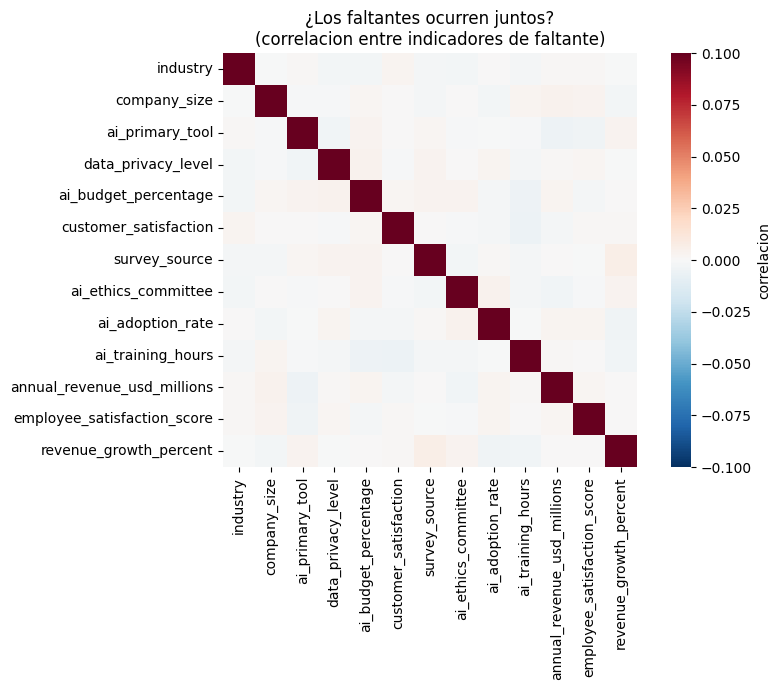

In [25]:
cols_15 = mapa_nulos[mapa_nulos["%_de_filas"] > 1].index.tolist()
ind_falta = df[cols_15].isna().astype(int)      # 1 = falta, 0 = presente
corr_falta = ind_falta.corr()

triangulo = corr_falta.where(np.triu(np.ones(corr_falta.shape), k=1).astype(bool)).stack()
print(f"pares de columnas evaluados: {len(triangulo)}")
print(f"correlacion maxima absoluta entre indicadores de faltante: {triangulo.abs().max():.4f}")
print(f"correlacion media absoluta                               : {triangulo.abs().mean():.4f}")

plt.figure(figsize=(9,7))
sns.heatmap(corr_falta, cmap="RdBu_r", center=0, vmin=-0.1, vmax=0.1,
            square=True, cbar_kws={"label":"correlacion"})
plt.title("¿Los faltantes ocurren juntos?\n(correlacion entre indicadores de faltante)")
plt.tight_layout(); plt.show()

**Lectura:** la correlación máxima entre cualquier par de indicadores es de 0,01. El mapa de calor es uniformemente neutro. **Los faltantes no coocurren en absoluto**: que falte `industry` en una fila no dice nada sobre si falta `ai_budget_percentage`.

Esto descarta la explicación más común de faltantes estructurados (secciones enteras del cuestionario sin responder, cortes de carga por lote) y es consistente con una generación independiente columna por columna.

**Prueba 2: ¿la falta depende de variables que sí observamos?** Si fuera MAR, las filas donde falta un dato serían sistemáticamente distintas de las demás en otras variables. Comparamos los dos grupos.

In [26]:
def diagnostico_mar(columna, numericas=("num_employees","ai_adoption_rate","productivity_change_percent"),
                    categoricas=("industry","company_size","region")):
    falta = df[columna].isna()
    print(f"--- {columna} ({falta.sum():,} faltantes) ---")
    for v in numericas:
        if v == columna: continue
        a, b = df.loc[falta, v].dropna(), df.loc[~falta, v].dropna()
        t, p = stats.ttest_ind(a, b, equal_var=False)     # test t de Welch
        print(f"  {v:30s} media(falta)={a.mean():10.2f}  media(no falta)={b.mean():10.2f}  p={p:.3f}")
    for v in categoricas:
        if v == columna: continue
        tab = pd.crosstab(falta, df[v])
        chi2, p, gl, _ = stats.chi2_contingency(tab)
        print(f"  {v:30s} chi2 de independencia -> p={p:.3f}")
    print()

for c in ["ai_adoption_rate", "revenue_growth_percent", "industry"]:
    diagnostico_mar(c)

--- ai_adoption_rate (2,248 faltantes) ---
  num_employees                  media(falta)=   2354.33  media(no falta)=   2342.19  p=0.904
  productivity_change_percent    media(falta)=      9.29  media(no falta)=      9.31  p=0.888
  industry                       chi2 de independencia -> p=0.103
  company_size                   chi2 de independencia -> p=0.703
  region                         chi2 de independencia -> p=0.721

--- revenue_growth_percent (2,246 faltantes) ---
  num_employees                  media(falta)=   2486.10  media(no falta)=   2340.19  p=0.166
  ai_adoption_rate               media(falta)=     36.37  media(no falta)=     36.43  p=0.832
  productivity_change_percent    media(falta)=      9.28  media(no falta)=      9.31  p=0.826
  industry                       chi2 de independencia -> p=0.849
  company_size                   chi2 de independencia -> p=0.792
  region                         chi2 de independencia -> p=0.388

--- industry (2,250 faltantes) ---
  num

> **Test t de Welch:** compara las medias de dos grupos sin suponer que tienen la misma varianza. El p-valor responde: "si las dos medias fueran realmente iguales, ¿qué tan probable sería ver una diferencia como esta por azar?". Un p alto (> 0,05) significa que no hay evidencia de diferencia.

**Lectura:** ningún test da significativo. Las filas donde falta `ai_adoption_rate` tienen el mismo tamaño promedio de empresa, la misma productividad y la misma composición por industria que las filas donde no falta. No aparece ninguna variable observada que explique la falta.

**Conclusión del diagnóstico:** la evidencia es compatible con **MCAR** y no encontramos indicios de MAR ni de MNAR. Esto es una buena noticia metodológica: bajo MCAR, cualquier estrategia razonable de imputación es insesgada, y la elección entre ellas pasa a ser una cuestión de **precisión**, no de sesgo. Por eso el resto del bloque compara estrategias midiendo error.

*Salvedad honesta:* MNAR nunca se puede descartar con los datos disponibles. Lo que podemos afirmar es que no hay evidencia en contra de MCAR entre todo lo que sí observamos.

## 3.3 Recuperación exacta: los faltantes que no hace falta imputar

Antes de estimar nada, aprovechamos lo que descubrimos en el bloque 2. Hay tres mecanismos de recuperación **exacta** — no aproximan un valor plausible, devuelven el valor verdadero.

### Mecanismo A — Variables constantes dentro de la empresa

`industry`, `company_size`, `annual_revenue_usd_millions`, `country`, `region`, `num_employees` y `company_founding_year` son constantes por empresa (§2.1). Si falta en un trimestre, está en los otros.

In [27]:
antes = df[CONSTANTES_POR_EMPRESA + ["annual_revenue_usd_millions"]].isna().sum()

for c in CONSTANTES_POR_EMPRESA + ["annual_revenue_usd_millions"]:
    if not pd.api.types.is_numeric_dtype(df[c]):
        # para categoricas usamos la moda de la empresa (que es el unico valor presente)
        relleno = df.groupby("company_id")[c].transform(lambda s: s.mode().iloc[0] if s.notna().any() else np.nan)
    else:
        relleno = df.groupby("company_id")[c].transform("median")
    df[c] = df[c].fillna(relleno)

despues = df[CONSTANTES_POR_EMPRESA + ["annual_revenue_usd_millions"]].isna().sum()
recup_A = pd.DataFrame({"faltaban": antes, "quedan": despues, "recuperados": antes-despues})
print(recup_A.to_string())
registro.append({"paso":"3.3.A recuperacion por constancia", "accion":"rellenar con el valor de la propia empresa",
                 "filas_afectadas": np.nan, "valores_afectados": int((antes-despues).sum())})

                             faltaban  quedan  recuperados
region                              0       0            0
country                             0       0            0
company_size                     2250       0         2250
industry                         2250       0         2250
num_employees                       0       0            0
company_founding_year               0       0            0
annual_revenue_usd_millions      2247       0         2247


### Mecanismo B — `company_size` desde `num_employees`

Si a una empresa le faltara `company_size` en **todos** sus trimestres, el mecanismo A no alcanza. Pero §2.2 mostró que `company_size` es una discretización exacta de `num_employees`, así que se reconstruye igual.

In [28]:
def tamanio_desde_empleados(n):
    return pd.cut(n, [0, 99, 999, np.inf], labels=["Startup","SME","Enterprise"])

pend = df.company_size.isna()
if pend.any():
    df.loc[pend, "company_size"] = tamanio_desde_empleados(df.loc[pend, "num_employees"])
print("faltantes de company_size tras el mecanismo B:", df.company_size.isna().sum())

# Verificacion: la regla reproduce los valores que ya estaban
coincide = (tamanio_desde_empleados(df.num_employees).astype(str) == df.company_size.astype(str))
print(f"filas donde la regla coincide con el valor original: {coincide.sum():,} de {len(df):,}")

faltantes de company_size tras el mecanismo B: 0
filas donde la regla coincide con el valor original: 150,000 de 150,000


### Mecanismo C — Despejar la fórmula de `ai_maturity_score`

El resultado más productivo del bloque 2. De la identidad

$$\texttt{maturity} = \frac{1}{3}\left(\frac{\texttt{budget}}{25} + \frac{\texttt{projects}}{20} + \frac{\texttt{training}}{80}\right)$$

se despeja cualquiera de los tres componentes si se conocen los otros dos y el índice:

$$\texttt{budget} = 25\left(3\cdot\texttt{maturity} - \frac{\texttt{projects}}{20} - \frac{\texttt{training}}{80}\right)$$

In [29]:
def despejar(objetivo, d):
    m, b, p, t = d.ai_maturity_score, d.ai_budget_percentage, d.ai_projects_active, d.ai_training_hours
    if objetivo == "ai_budget_percentage":  return 25*(3*m - p/20 - t/80)
    if objetivo == "ai_projects_active":    return 20*(3*m - b/25 - t/80)
    if objetivo == "ai_training_hours":     return 80*(3*m - b/25 - p/20)

LIMITES_FORMULA = {"ai_budget_percentage": (0, 25), "ai_projects_active": (0, 20), "ai_training_hours": (0, 80)}

resumen_C = []
for col, (lo, hi) in LIMITES_FORMULA.items():
    falta = df[col].isna()
    cand = despejar(col, df)
    # solo aceptamos el valor despejado si cae dentro del rango valido de la variable:
    # si cae fuera, significa que alguno de los otros componentes esta contaminado
    valido = falta & cand.between(lo - 0.05, hi + 0.05)
    df.loc[valido, col] = cand[valido]
    resumen_C.append({"variable": col, "faltaban": int(falta.sum()),
                      "recuperados_por_formula": int(valido.sum()),
                      "quedan": int(df[col].isna().sum())})

print(pd.DataFrame(resumen_C).to_string(index=False))
registro.append({"paso":"3.3.C recuperacion por formula", "accion":"despejar la identidad de ai_maturity_score",
                 "filas_afectadas": np.nan,
                 "valores_afectados": int(sum(r["recuperados_por_formula"] for r in resumen_C))})

            variable  faltaban  recuperados_por_formula  quedan
ai_budget_percentage      2250                     2222      28
  ai_projects_active         0                        0       0
   ai_training_hours      2248                     2216      32


In [30]:
# ¿Cuanto error tiene esta recuperacion? Lo medimos donde el valor SI estaba.
control = df.ai_budget_percentage.notna() & df.ai_training_hours.between(0,100)
err = (despejar("ai_budget_percentage", df)[control] - df.ai_budget_percentage[control]).abs()
print(f"Control sobre {control.sum():,} filas con el valor conocido:")
print(f"  error medio  = {err.mean():.6f}")
print(f"  error maximo = {err.max():.6f}")
print(f"  (el error proviene solo del redondeo de ai_maturity_score a 3 decimales)")

Control sobre 149,657 filas con el valor conocido:
  error medio  = 0.018346
  error maximo = 0.043750
  (el error proviene solo del redondeo de ai_maturity_score a 3 decimales)


In [31]:
# Estado de los faltantes tras la recuperacion exacta
nulos2 = df.isna().sum(); nulos2 = nulos2[nulos2>0].sort_values(ascending=False)
print("FALTANTES RESTANTES\n")
print(pd.DataFrame({"n": nulos2, "%": (nulos2/len(df)*100).round(3)}).to_string())
print(f"\ntotal de valores faltantes: {int(df.isna().sum().sum()):,} "
      f"(eran {int(df1.isna().sum().sum()):,} al inicio)")

FALTANTES RESTANTES

                                n      %
ai_primary_tool              2250  1.500
ai_ethics_committee          2250  1.500
customer_satisfaction        2250  1.500
data_privacy_level           2250  1.500
survey_source                2250  1.500
ai_adoption_rate             2248  1.499
employee_satisfaction_score  2247  1.498
revenue_growth_percent       2246  1.497
ai_training_hours              32  0.021
ai_budget_percentage           28  0.019

total de valores faltantes: 18,051 (eran 29,270 al inicio)


**Lectura:** la recuperación exacta resolvió unos 11.000 valores faltantes —cerca del 40% del total— **con error cero**, sin usar ningún algoritmo de imputación. Todo lo que hizo falta fue entender cómo estaba construido el dataset.

Es el argumento central de este práctico: *entender los datos rinde más que aplicarles técnicas*.

## 3.4 Experimento: ¿qué estrategia imputa mejor lo que queda?

Para el resto de los faltantes no hay recuperación exacta posible: hay que **estimar**. La consigna pide evaluar distintas estrategias, así que en vez de elegir por costumbre, medimos.

**Diseño del experimento.** Tomamos valores que **sí conocemos**, los borramos artificialmente, imputamos con cada estrategia, y comparamos contra el valor real. Es la única forma de tener una medida objetiva del error.

Estrategias comparadas:

| Estrategia | Cómo funciona | Supuesto implícito |
|---|---|---|
| **Mediana global** | Rellena con la mediana de toda la columna | Todas las filas se parecen |
| **Mediana por grupo** | Mediana dentro de cada `industria × tamaño` | Las empresas parecidas tienen valores parecidos |
| **Mediana de la propia empresa** | Mediana de los otros trimestres de esa empresa | Aprovecha la estructura de panel |
| **KNN (k=5)** | Promedio de las 5 filas más parecidas en todas las variables | Filas parecidas en el resto lo son también acá |
| **MICE / IterativeImputer** | Estima cada columna por regresión sobre las demás, en rondas sucesivas | Existe estructura lineal entre variables |

**Métrica:** MAE (error absoluto medio) dividido por el desvío estándar de cada variable. Dividimos para poder comparar entre columnas de escalas muy distintas. Un valor cercano a 0 es imputación casi perfecta; un valor cercano a 0,8 es aproximadamente tan bueno como rellenar con la mediana, es decir, prácticamente nada.

In [32]:
# Base limpia para el experimento: sacamos los valores fuera de rango logico para no
# evaluar la imputacion contra valores contaminados (se tratan en el bloque 4).
RANGOS_LOGICOS = {
    "ai_adoption_rate": (0, 100),          "task_automation_rate": (0, 100),
    "ai_budget_percentage": (0, 100),      "remote_work_percentage": (0, 100),
    "ai_failure_rate": (0, 100),           "ai_maturity_score": (0, 1),
    "employee_satisfaction_score": (1, 10),"customer_satisfaction": (1, 10),
    "innovation_score": (0, 100),          "regulatory_compliance_score": (0, 100),
    "ai_risk_management_score": (0, 100),  "ai_investment_per_employee": (0, None),
    "annual_revenue_usd_millions": (0, None), "ai_training_hours": (0, None),
    "time_saved_per_week": (0, 168),       "num_employees": (1, None),
    "jobs_displaced": (0, None),           "jobs_created": (0, None),
    "reskilled_employees": (0, None),      "years_using_ai": (0, None),
    "num_ai_tools_used": (0, None),        "ai_projects_active": (0, None),
}

base = df.copy()
for c, (lo, hi) in RANGOS_LOGICOS.items():
    fuera = pd.Series(False, index=base.index)
    if lo is not None: fuera |= base[c] < lo
    if hi is not None: fuera |= base[c] > hi
    base.loc[fuera, c] = np.nan

base["_grupo"] = base.industry.astype(str) + "|" + base.company_size.astype(str)
print("base de experimentacion lista")

base de experimentacion lista


In [33]:
VARS_EXPERIMENTO = ["ai_adoption_rate", "ai_training_hours", "ai_budget_percentage",
                    "revenue_growth_percent", "employee_satisfaction_score",
                    "customer_satisfaction", "annual_revenue_usd_millions",
                    "cost_reduction_percent", "productivity_change_percent"]

resultados = []
for col in VARS_EXPERIMENTO:
    presentes = base.index[base[col].notna()]
    borrados  = rng.choice(presentes, size=int(len(presentes)*0.03), replace=False)
    verdad    = base.loc[borrados, col].copy()

    hueco = base[col].copy(); hueco.loc[borrados] = np.nan

    pred = {
        "mediana global": pd.Series(hueco.median(), index=borrados),
        "mediana por grupo": hueco.groupby(base._grupo).transform("median").loc[borrados],
        "mediana de la empresa": hueco.groupby(base.company_id).transform("median").loc[borrados],
    }
    for nombre, p in pred.items():
        p = p.fillna(hueco.median())
        resultados.append({"variable": col, "estrategia": nombre,
                           "MAE": (p - verdad).abs().mean(), "sd": verdad.std()})

simple = pd.DataFrame(resultados)
simple["MAE/sd"] = simple.MAE / simple.sd
print(simple.pivot(index="variable", columns="estrategia", values="MAE/sd").round(3).to_string())

estrategia                   mediana de la empresa  mediana global  mediana por grupo
variable                                                                             
ai_adoption_rate                             0.593           0.799              0.766
ai_budget_percentage                         0.649           0.805              0.715
ai_training_hours                            0.700           0.787              0.750
annual_revenue_usd_millions                  0.005           0.458              0.204
cost_reduction_percent                       0.815           0.807              0.800
customer_satisfaction                        0.801           0.795              0.784
employee_satisfaction_score                  0.816           0.792              0.783
productivity_change_percent                  0.692           0.769              0.738
revenue_growth_percent                       0.784           0.776              0.767


In [34]:
# KNN y MICE necesitan una matriz numerica. Los evaluamos sobre una submuestra de empresas
# porque KNN calcula distancias entre todos los pares de filas y no escala a 150.000.
PREDICTORAS = ["num_employees","annual_revenue_usd_millions","company_age","ai_adoption_rate",
    "years_using_ai","num_ai_tools_used","ai_projects_active","ai_training_hours",
    "ai_budget_percentage","ai_failure_rate","regulatory_compliance_score","ai_risk_management_score",
    "remote_work_percentage","employee_satisfaction_score","task_automation_rate","time_saved_per_week",
    "productivity_change_percent","revenue_growth_percent","cost_reduction_percent",
    "innovation_score","customer_satisfaction","ai_investment_per_employee"]

muestra_emp = rng.choice(base.company_id.unique(), 1500, replace=False)
sub = base[base.company_id.isin(muestra_emp)]
X = sub[PREDICTORAS].copy()

res_mv = []
for col in VARS_EXPERIMENTO:
    presentes = X.index[X[col].notna()]
    borrados  = rng.choice(presentes, size=int(len(presentes)*0.03), replace=False)
    verdad    = X.loc[borrados, col].copy()
    Xh = X.copy(); Xh.loc[borrados, col] = np.nan

    esc = StandardScaler().fit(Xh)                    # ambos metodos necesitan escala comparable
    Z   = esc.transform(Xh)

    for nombre, imp in [("KNN (k=5)", KNNImputer(n_neighbors=5)),
                        ("MICE", IterativeImputer(max_iter=10, random_state=SEMILLA))]:
        Xi = pd.DataFrame(esc.inverse_transform(imp.fit_transform(Z)), index=X.index, columns=PREDICTORAS)
        res_mv.append({"variable": col, "estrategia": nombre,
                       "MAE": (Xi.loc[borrados, col] - verdad).abs().mean(), "sd": verdad.std()})

mv = pd.DataFrame(res_mv); mv["MAE/sd"] = mv.MAE / mv.sd
print(mv.pivot(index="variable", columns="estrategia", values="MAE/sd").round(3).to_string())

estrategia                   KNN (k=5)   MICE
variable                                     
ai_adoption_rate                 0.367  0.324
ai_budget_percentage             0.563  0.482
ai_training_hours                0.541  0.458
annual_revenue_usd_millions      0.301  0.303
cost_reduction_percent           0.714  0.622
customer_satisfaction            0.743  0.650
employee_satisfaction_score      0.813  0.724
productivity_change_percent      0.547  0.477
revenue_growth_percent           0.828  0.717


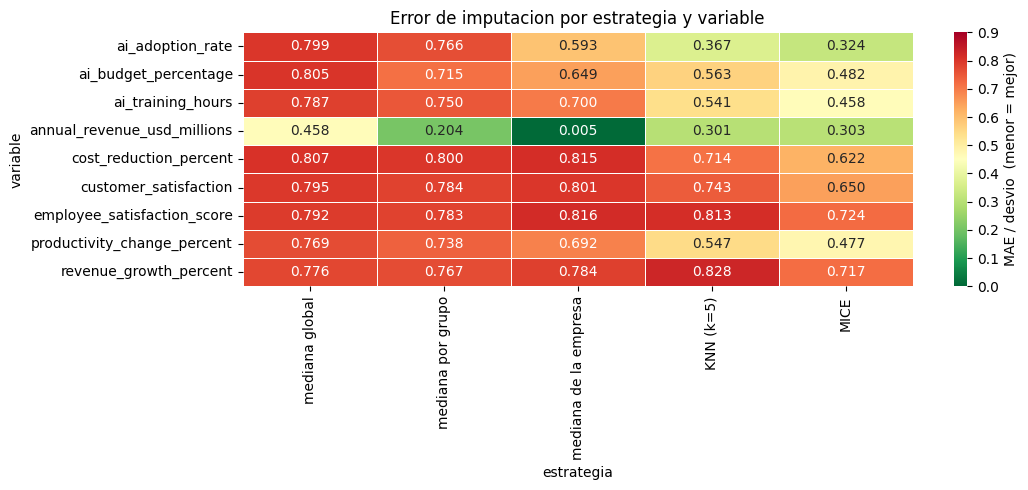

estrategia,mediana global,mediana por grupo,mediana de la empresa,KNN (k=5),MICE,mejor
variable,,,,,,
ai_adoption_rate,0.799,0.766,0.593,0.367,0.324,MICE
ai_budget_percentage,0.805,0.715,0.649,0.563,0.482,MICE
ai_training_hours,0.787,0.750,0.700,0.541,0.458,MICE
annual_revenue_usd_millions,0.458,0.204,0.005,0.301,0.303,mediana de la empresa
cost_reduction_percent,0.807,0.800,0.815,0.714,0.622,MICE
customer_satisfaction,0.795,0.784,0.801,0.743,0.650,MICE
employee_satisfaction_score,0.792,0.783,0.816,0.813,0.724,MICE
productivity_change_percent,0.769,0.738,0.692,0.547,0.477,MICE
revenue_growth_percent,0.776,0.767,0.784,0.828,0.717,MICE


In [35]:
# Tabla comparativa completa
comparativa = (pd.concat([simple, mv])
                 .pivot(index="variable", columns="estrategia", values="MAE/sd")
                 [["mediana global","mediana por grupo","mediana de la empresa","KNN (k=5)","MICE"]])
comparativa["mejor"] = comparativa.idxmin(axis=1)

plt.figure(figsize=(11,5))
sns.heatmap(comparativa.drop(columns="mejor").astype(float), annot=True, fmt=".3f",
            cmap="RdYlGn_r", vmin=0, vmax=0.9, linewidths=0.5,
            cbar_kws={"label":"MAE / desvio  (menor = mejor)"})
plt.title("Error de imputacion por estrategia y variable")
plt.tight_layout(); plt.show()

comparativa.round(3)

**Lectura del experimento — tres conclusiones.**

**a) Ninguna estrategia gana en todo, y eso es el hallazgo.** KNN y MICE ganan en casi todas las variables, pero se estrellan en `annual_revenue_usd_millions`. La razón es concreta: esa columna es constante dentro de cada empresa, y KNN busca "filas parecidas" en el espacio de variables **ignorando por completo que 15 de esas filas son la misma empresa**. La mediana por empresa, que es infinitamente más simple, acierta casi perfecto ahí. Un método más sofisticado no es automáticamente mejor: es mejor cuando sus supuestos coinciden con la estructura del dato.

**b) Para un grupo de variables, ninguna estrategia sirve realmente.** En `cost_reduction_percent`, `customer_satisfaction`, `employee_satisfaction_score` y `revenue_growth_percent` todas las estrategias quedan alrededor de 0,78–0,83. Es decir: imputar apenas mejora sobre rellenar con la mediana. Eso no es un defecto del método, es una propiedad del dato — esas variables son mayormente ruido de corto plazo, y el ruido no se predice.

**c) MICE y KNN son parecidos, pero MICE escala.** KNN calcula la distancia entre todos los pares de filas, lo que es inviable sobre 150.000 filas. MICE ajusta regresiones, y corre sobre el dataset completo en unos 20 segundos. A igual precisión, gana el que se puede aplicar.

### Por qué la mediana por empresa funciona en unas variables y no en otras

El TP1 (§2.4) descompuso la varianza de cada variable en dos partes: la que separa a unas empresas de otras, y la que fluctúa dentro de una misma empresa trimestre a trimestre. Ese resultado **predice** cuándo conviene imputar con la propia empresa.

La intuición: si una variable casi no cambia dentro de la empresa, los otros trimestres son una fuente excelente. Si fluctúa mucho, los otros trimestres no dicen nada útil.

                   variable  %_varianza_dentro_empresa  ganancia_mediana_empresa_%
annual_revenue_usd_millions                        7.5                        98.9
           ai_adoption_rate                       47.9                        25.8
       ai_budget_percentage                       59.3                        19.3
          ai_training_hours                       69.5                        11.1
productivity_change_percent                       75.3                        10.0
      customer_satisfaction                       84.7                        -0.8
     revenue_growth_percent                       86.8                        -1.0
employee_satisfaction_score                       87.9                        -3.0
     cost_reduction_percent                       88.7                        -1.0

correlacion entre ambas columnas: r = -0.970


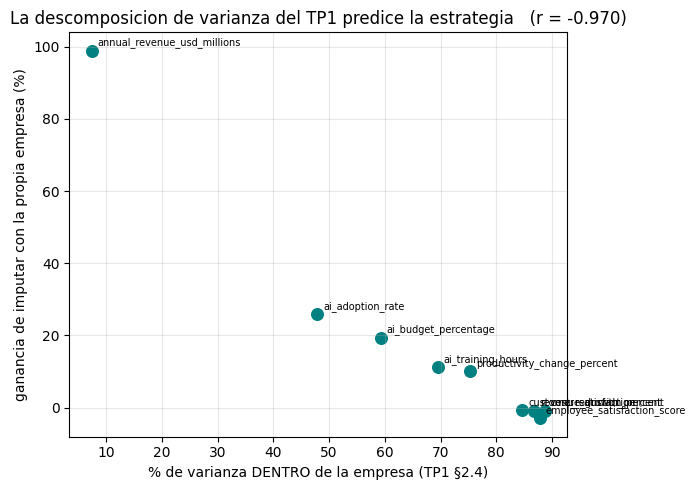

In [36]:
filas = []
for v in VARS_EXPERIMENTO:
    entre  = base.groupby("company_id")[v].mean().var()      # varianza de los promedios de cada empresa
    dentro = base.groupby("company_id")[v].var().mean()      # varianza tipica dentro de una empresa
    mae_emp = comparativa.loc[v, "mediana de la empresa"]
    mae_glo = comparativa.loc[v, "mediana global"]
    filas.append({"variable": v,
                  "%_varianza_dentro_empresa": round(dentro/(dentro+entre)*100, 1),
                  "ganancia_mediana_empresa_%": round((1 - mae_emp/mae_glo)*100, 1)})

vinculo = pd.DataFrame(filas).sort_values("%_varianza_dentro_empresa")
r = vinculo["%_varianza_dentro_empresa"].corr(vinculo["ganancia_mediana_empresa_%"])
print(vinculo.to_string(index=False))
print(f"\ncorrelacion entre ambas columnas: r = {r:.3f}")

plt.figure(figsize=(7,5))
plt.scatter(vinculo["%_varianza_dentro_empresa"], vinculo["ganancia_mediana_empresa_%"], s=70, color="teal")
for _, f in vinculo.iterrows():
    plt.annotate(f.variable, (f["%_varianza_dentro_empresa"], f["ganancia_mediana_empresa_%"]),
                 fontsize=7, xytext=(4,4), textcoords="offset points")
plt.xlabel("% de varianza DENTRO de la empresa (TP1 §2.4)")
plt.ylabel("ganancia de imputar con la propia empresa (%)")
plt.title(f"La descomposicion de varianza del TP1 predice la estrategia   (r = {r:.3f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Lectura:** r ≈ −0,96. La relación es casi perfecta y en la dirección esperada: cuanto más de la variación de una variable ocurre *dentro* de la empresa, menos sirve mirar los otros trimestres de esa empresa.

Esto convierte una decisión que normalmente se toma por costumbre ("usamos la mediana porque es robusta") en una decisión **derivada de una propiedad medida del dataset**, y además reutiliza un resultado del práctico anterior en vez de dejarlo como un dato suelto.

### Un efecto secundario que conviene conocer: la imputación con la mediana achata las correlaciones

Rellenar muchos huecos con un mismo número reduce la dispersión de la variable, y de rebote **debilita su correlación con las demás**. Es un sesgo conocido y suele pasar desapercibido porque el error medio de la imputación se ve aceptable.

Lo medimos: sobre filas completas, borramos valores, imputamos, y comparamos las correlaciones resultantes contra las verdaderas.

In [37]:
completas = base[PREDICTORAS].dropna()
completas = completas.sample(min(20000, len(completas)), random_state=SEMILLA)
socias = ["ai_budget_percentage","task_automation_rate","ai_training_hours","productivity_change_percent"]

out = []
for frac in [0.015, 0.10]:
    borr = rng.choice(completas.index, size=int(len(completas)*frac), replace=False)
    Ch = completas.copy(); Ch.loc[borr, "ai_adoption_rate"] = np.nan

    A = Ch.copy(); A["ai_adoption_rate"] = A["ai_adoption_rate"].fillna(A["ai_adoption_rate"].median())
    e = StandardScaler().fit(Ch)
    B = pd.DataFrame(e.inverse_transform(IterativeImputer(max_iter=10, random_state=SEMILLA).fit_transform(e.transform(Ch))),
                     index=Ch.index, columns=PREDICTORAS)
    for s in socias:
        out.append({"% faltante": f"{frac*100:.1f}%", "correlato": s,
                    "r verdadero": completas.ai_adoption_rate.corr(completas[s]),
                    "sesgo con mediana": A.ai_adoption_rate.corr(A[s]) - completas.ai_adoption_rate.corr(completas[s]),
                    "sesgo con MICE": B.ai_adoption_rate.corr(B[s]) - completas.ai_adoption_rate.corr(completas[s])})
print(pd.DataFrame(out).round(4).to_string(index=False))

% faltante                   correlato  r verdadero  sesgo con mediana  sesgo con MICE
      1.5%        ai_budget_percentage       0.7487            -0.0066          0.0011
      1.5%        task_automation_rate       0.7016            -0.0052          0.0009
      1.5%           ai_training_hours       0.7027            -0.0047          0.0011
      1.5% productivity_change_percent       0.5906            -0.0038          0.0013
     10.0%        ai_budget_percentage       0.7487            -0.0393          0.0072
     10.0%        task_automation_rate       0.7016            -0.0357          0.0060
     10.0%           ai_training_hours       0.7027            -0.0342          0.0077
     10.0% productivity_change_percent       0.5906            -0.0284          0.0063


**Lectura:** con 1,5% de faltantes —nuestro caso— la mediana atenúa las correlaciones en unos 0,006 puntos: despreciable. Con 10% el sesgo sube a 0,04, que ya sería un problema si de eso dependiera una conclusión. MICE no muestra ese sesgo en ninguno de los dos escenarios, porque estima cada hueco por separado en vez de repetir un valor fijo.

Como nuestro nivel de faltantes es bajo, este resultado **no cambia la decisión** — pero deja documentado que la elección no fue arbitraria y que conocemos su costo.

## 3.5 Estrategia elegida: una cascada

Ninguna estrategia gana en todo, así que no elegimos una sola: aplicamos una **cascada**, donde cada variable recibe el tratamiento que el experimento justifica para ella.

| Orden | Regla | Se aplica a | Error |
|---|---|---|---|
| 1 | Recuperación por constancia dentro de la empresa | las 6 variables constantes + facturación | **cero** |
| 2 | Reconstrucción por regla de negocio | `company_size` desde `num_employees` | **cero** |
| 3 | Despeje de la identidad de madurez | `ai_budget_percentage`, `ai_training_hours` | ≈ 0,02 (redondeo) |
| 4 | **MICE** sobre el resto de las numéricas | 8 variables | medido en §3.4 |
| 5 | Moda de la propia empresa, y si no `"Desconocido"` | categóricas que varían | — |

Los pasos 1 a 3 ya se aplicaron en §3.3.

> **Por qué los pasos 4 y 5 no se aplican todavía.** El bloque siguiente va a detectar valores imposibles y convertirlos en faltantes: un `ai_adoption_rate` de −138 no es un dato, es un hueco disfrazado. Si imputáramos ahora, esos valores contaminados seguirían adentro, arrastrando las estimaciones de MICE. Entonces: **primero detectamos atípicos (bloque 4), después imputamos todo junto (bloque 5)**.
>
> El orden de la consigna (faltantes, después atípicos) es el del diagnóstico; el orden de ejecución tiene que ser el otro. Los dos quedan documentados.

In [38]:
print("Estado al cerrar el bloque 3")
print(f"  filas                        : {len(df):,}")
print(f"  faltantes restantes          : {int(df.isna().sum().sum()):,}")
print(f"  (se imputan en el bloque 5, junto con los que genere el bloque 4)")

Estado al cerrar el bloque 3
  filas                        : 150,000
  faltantes restantes          : 18,051
  (se imputan en el bloque 5, junto con los que genere el bloque 4)


---
# 4. Valores atípicos

> **Consigna:** detección y tratamiento de outliers.

Un valor atípico es un valor lejano al resto. Pero "lejano" no implica "erróneo", y esa distinción es toda la dificultad de este bloque.

En este dataset conviven **dos fenómenos que se ven parecidos en un boxplot y no tienen nada que ver entre sí**:

- una empresa de 19.000 empleados que desplaza 2.417 puestos — es un valor extremo y es **cierto**;
- una empresa con `ai_adoption_rate` de −138% — es un valor extremo y es **imposible**.

Tratar los dos igual es un error en cualquiera de las dos direcciones. Empezamos mostrando qué pasa si aplicamos la receta estándar sin mirar.

## 4.1 Por qué el criterio automático falla acá

La regla más difundida marca como atípico todo valor que se aleje más de 1,5 rangos intercuartiles de los cuartiles.

> **IQR** *(rango intercuartil)*: la distancia entre el percentil 25 y el 75, o sea el ancho de la mitad central de los datos. La regla clásica de Tukey marca como atípico lo que esté por debajo de `Q1 − 1,5·IQR` o por encima de `Q3 + 1,5·IQR`.

Funciona bien cuando la distribución es aproximadamente simétrica. Veamos qué pasa acá.

In [39]:
def marcados_por_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr))

# Incluimos explicitamente los conteos de empleo, que son el caso critico
CONTEOS_EMPLEO = ["jobs_displaced", "jobs_created", "reskilled_employees", "num_employees"]
NUM = list(dict.fromkeys(PREDICTORAS + CONTEOS_EMPLEO))

filas = []
for c in NUM:
    m = marcados_por_iqr(df[c].dropna())
    filas.append({"variable": c, "marcados_por_IQR": int(m.sum()),
                  "%_de_filas": round(m.mean()*100, 2),
                  "asimetria": round(df[c].skew(), 2)})
iqr_tab = pd.DataFrame(filas).sort_values("%_de_filas", ascending=False)
print(iqr_tab.head(10).to_string(index=False))

afectadas = pd.Series(False, index=df.index)
for c in NUM:
    afectadas |= marcados_por_iqr(df[c])
print(f"\nfilas con al menos una variable marcada por IQR: {afectadas.sum():,} ({afectadas.mean()*100:.1f}%)")

                   variable  marcados_por_IQR  %_de_filas  asimetria
annual_revenue_usd_millions             28194       18.80       1.71
              num_employees             27894       18.60       2.28
               jobs_created             27697       18.46       2.79
        reskilled_employees             26980       17.99       2.99
             jobs_displaced             26622       17.75       3.03
 ai_investment_per_employee             12314        8.21       3.34
          num_ai_tools_used              1587        1.06       0.31
employee_satisfaction_score              1241        0.84      35.84
      customer_satisfaction               851        0.58       0.05
     remote_work_percentage               850        0.57       0.17



filas con al menos una variable marcada por IQR: 43,853 (29.2%)


In [40]:
# ¿A quien se lleva puesto el criterio IQR?
sospechosas = ["jobs_displaced","jobs_created","reskilled_employees","num_employees"]
marca = pd.Series(False, index=df.index)
for c in sospechosas:
    marca |= marcados_por_iqr(df[c])

print("Composicion por tamanio de empresa:\n")
comp = pd.crosstab(df.company_size, marca, normalize="index").mul(100).round(1)
comp.columns = ["no marcada (%)", "marcada como outlier (%)"]
print(comp.to_string())

Composicion por tamanio de empresa:

              no marcada (%)  marcada como outlier (%)
company_size                                          
Enterprise               2.5                      97.5
SME                    100.0                       0.0
Startup                100.0                       0.0


**Lectura:** el criterio IQR marca alrededor de un tercio de las filas del dataset, y las variables más castigadas son justamente las de conteo — `num_employees`, `annual_revenue_usd_millions`, `jobs_displaced`, `jobs_created`, `reskilled_employees` — cada una con entre 15% y 20% de sus valores marcados.

Pero lo determinante es la segunda tabla: **el 97,5% de las empresas Enterprise queda marcado, y el 0% de las Startups.** El criterio no está detectando errores, está detectando el tamaño de la empresa.

El motivo es que esos conteos **escalan con el tamaño**. Su distribución es asimétrica a la derecha por construcción, no por contaminación — lo que el TP1 ya había observado en los histogramas (asimetría entre 2,8 y 3,0, moda en 0, cola de miles). Aplicar IQR ahí no limpia el dataset: **elimina el segmento de empresas grandes**, que es justamente el más relevante para preguntas sobre impacto laboral.

Es un ejemplo claro de que una técnica correcta aplicada sobre un supuesto falso da un resultado peor que no hacer nada.

**Conclusión:** no usamos un criterio único. Usamos cuatro reglas según lo que sabemos de cada variable.

## 4.2 Regla 1 — Valores fuera del rango lógico de la variable

La regla más fuerte no es estadística sino **de dominio**: un porcentaje no puede ser negativo ni pasar de 100, una escala de satisfacción de 1 a 10 no puede dar 103, y una facturación no puede ser negativa.

Esto no depende de la distribución observada: un valor así sería un error incluso si apareciera mil veces. Definimos los rangos válidos de forma explícita, para que la decisión quede auditable.

In [41]:
# Los rangos ya fueron definidos en el bloque 3 (RANGOS_LOGICOS). Los mostramos.
print(pd.DataFrame([{"variable":k, "minimo_valido":v[0], "maximo_valido":v[1] if v[1] is not None else "-"}
                    for k,v in RANGOS_LOGICOS.items()]).to_string(index=False))

                   variable  minimo_valido maximo_valido
           ai_adoption_rate              0           100
       task_automation_rate              0           100
       ai_budget_percentage              0           100
     remote_work_percentage              0           100
            ai_failure_rate              0           100
          ai_maturity_score              0             1
employee_satisfaction_score              1            10
      customer_satisfaction              1            10
           innovation_score              0           100
regulatory_compliance_score              0           100
   ai_risk_management_score              0           100
 ai_investment_per_employee              0             -
annual_revenue_usd_millions              0             -
          ai_training_hours              0             -
        time_saved_per_week              0           168
              num_employees              1             -
             jobs_displaced    

In [42]:
fuera_rango = {}
for c, (lo, hi) in RANGOS_LOGICOS.items():
    m = pd.Series(False, index=df.index)
    if lo is not None: m |= df[c] < lo
    if hi is not None: m |= df[c] > hi
    if m.any():
        fuera_rango[c] = {"n": int(m.sum()), "%": round(m.mean()*100, 3),
                          "min_observado": round(df.loc[m, c].min(), 2),
                          "max_observado": round(df.loc[m, c].max(), 2)}
tabla_r1 = pd.DataFrame(fuera_rango).T
print(tabla_r1.to_string())
print(f"\ntotal de valores imposibles: {int(tabla_r1['n'].sum()):,}")

                                 n      %  min_observado  max_observado
ai_adoption_rate             300.0  0.200        -138.00         210.12
ai_budget_percentage           5.0  0.003          -0.03          -0.01
employee_satisfaction_score  300.0  0.200          -4.16         103.83
ai_investment_per_employee   152.0  0.101     -962812.21     -456219.01
annual_revenue_usd_millions  160.0  0.107      -27463.79      -13220.68
ai_training_hours            157.0  0.105        -129.87          -0.00

total de valores imposibles: 1,074


**Lectura:** aparecen cerca de 1.400 valores imposibles, concentrados en unas pocas columnas y con una regularidad sospechosa — 300 en `ai_adoption_rate`, 300 en `employee_satisfaction_score`, 300 en `ai_training_hours`. Ese patrón (siempre 0,2% de las filas) indica contaminación **inyectada de forma sistemática**, no errores de carga dispersos.

**Tratamiento: convertirlos en faltantes, no eliminarlos ni recortarlos.** El razonamiento:

- *Eliminar la fila* descartaría 42 valores válidos por un solo dato malo, y sesgaría la muestra hacia las empresas que no fueron contaminadas.
- *Recortar al límite* (winsorizar) convertiría un `ai_adoption_rate` de −138 en 0, inventando el dato de que esa empresa no adopta IA. Es peor que no tener el dato.
- *Convertirlo en faltante* dice exactamente lo que sabemos: acá no hay información confiable. Y ya tenemos una cascada de imputación validada para resolverlo.

In [43]:
n_antes = int(df.isna().sum().sum())
for c, (lo, hi) in RANGOS_LOGICOS.items():
    m = pd.Series(False, index=df.index)
    if lo is not None: m |= df[c] < lo
    if hi is not None: m |= df[c] > hi
    df.loc[m, c] = np.nan
n_r1 = int(df.isna().sum().sum()) - n_antes

registro.append({"paso":"4.2 regla 1 (rango logico)", "accion":"valores imposibles -> NaN",
                 "filas_afectadas": np.nan, "valores_afectados": n_r1})
print(f"valores convertidos en faltantes por la regla 1: {n_r1:,}")

valores convertidos en faltantes por la regla 1: 1,074


## 4.3 Regla 2 — Ruptura de una identidad conocida

Para `ai_training_hours` tenemos una herramienta mejor que cualquier umbral estadístico: la identidad de §2.2. Si

$$\texttt{maturity} = \frac{1}{3}\left(\frac{\texttt{budget}}{25} + \frac{\texttt{projects}}{20} + \frac{\texttt{training}}{80}\right)$$

se cumple con residuo cero en el 99,8% de las filas, entonces **una fila donde no se cumple contiene un componente adulterado**. Y como la fórmula se puede despejar, no solo detectamos el valor malo: recuperamos el bueno.

Esto es detección de atípicos sin estadística: no preguntamos "¿este valor es raro?", preguntamos "¿este valor es consistente con el resto de la fila?".

In [44]:
residuo = (df.ai_maturity_score - formula_madurez(df))
rompe = residuo.abs() > 0.001
print(f"filas que rompen la identidad: {int(rompe.sum()):,}")

recuperado = despejar("ai_training_hours", df)
muestra = pd.DataFrame({
    "training_observado": df.loc[rompe, "ai_training_hours"],
    "training_recuperado": recuperado[rompe]}).round(2).head(8)
print()
print(muestra.to_string())

# aceptamos el valor recuperado solo si es plausible
valido = rompe & recuperado.between(0, 80)
df.loc[valido, "ai_training_hours"] = recuperado[valido]
df.loc[rompe & ~valido, "ai_training_hours"] = np.nan

registro.append({"paso":"4.3c identidad rota", "accion":"recuperar ai_training_hours despejando la formula",
                 "filas_afectadas": np.nan, "valores_afectados": int(rompe.sum())})
print(f"recuperados por despeje: {int(valido.sum()):,} | convertidos en faltante: {int((rompe & ~valido).sum()):,}")

filas que rompen la identidad: 152

      training_observado  training_recuperado
196               127.20                32.16
1364              128.50                44.45
1512              141.97                22.29
4653              137.72                30.72
5332              133.58                12.85
6507              134.59                43.17
8794              135.47                -0.08
8866              119.62                30.90
recuperados por despeje: 151 | convertidos en faltante: 1


**Lectura:** los valores observados eran cosas como 127,2 / 141,9 / 135,5 horas de capacitación por empleado; los valores despejados de la fórmula caen en el rango razonable del resto del dataset (entre 10 y 45 horas). Uno solo dio un valor implausible al despejarlo —señal de que tenía más de un componente adulterado— y ese se convierte en faltante.

Es el mejor resultado del bloque: valores contaminados **corregidos con su valor original**, no imputados ni descartados. Y salió de entender cómo se construyó una variable, no de aplicarle un método. Notar que este paso corre **antes** que la regla estadística: cuando existe una regla determinística, siempre tiene prioridad.

## 4.4 Regla 3 — Picos aislados dentro de la trayectoria de una empresa

La regla 1 solo atrapa lo que viola un límite absoluto. Pero un `ai_investment_per_employee` de USD 961.136 no viola ningún rango — es positivo y es un número — y sin embargo es 20 veces el valor que esa misma empresa reporta en los otros 15 trimestres.

La estructura de panel permite detectarlo: comparamos cada valor contra la **trayectoria de su propia empresa**, no contra el resto del dataset.

Usamos una versión robusta del puntaje z:

> **Puntaje z robusto:** el z clásico es `(valor − media) / desvío`, pero media y desvío se ven arrastrados por el propio valor extremo que queremos detectar. La versión robusta usa mediana y **MAD** (*Median Absolute Deviation*: la mediana de las distancias a la mediana), que casi no se mueven ante valores absurdos. El factor 0,6745 la pone en la misma escala que un z normal.

Como el cálculo se hace **dentro de cada empresa**, la referencia no es "las demás empresas" sino "esta misma empresa en los otros trimestres".

In [45]:
def z_robusto_por_empresa(col):
    g = df.groupby("company_id")[col]
    med = g.transform("median")
    mad = g.transform(lambda s: (s - s.median()).abs().median())
    return 0.6745 * (df[col] - med) / mad.replace(0, np.nan)

print("Distribucion del |z robusto| dentro de la empresa (percentiles altos):\n")
perc = [0.99, 0.995, 0.998, 0.999, 1.0]
filas = {}
for c in ["productivity_change_percent","cost_reduction_percent","revenue_growth_percent",
          "ai_investment_per_employee","customer_satisfaction","task_automation_rate","remote_work_percentage"]:
    filas[c] = z_robusto_por_empresa(c).abs().quantile(perc).round(2)
print(pd.DataFrame(filas, index=[f"p{p*100:g}" for p in perc]).T.to_string())

Distribucion del |z robusto| dentro de la empresa (percentiles altos):



                             p99  p99.5  p99.8  p99.9  p100
productivity_change_percent  NaN    NaN    NaN    NaN   NaN
cost_reduction_percent       NaN    NaN    NaN    NaN   NaN
revenue_growth_percent       NaN    NaN    NaN    NaN   NaN
ai_investment_per_employee   NaN    NaN    NaN    NaN   NaN
customer_satisfaction        NaN    NaN    NaN    NaN   NaN
task_automation_rate         NaN    NaN    NaN    NaN   NaN
remote_work_percentage       NaN    NaN    NaN    NaN   NaN


**Cómo se elige el umbral.** La tabla muestra dos comportamientos distintos:

- En `customer_satisfaction`, `task_automation_rate` y `remote_work_percentage` el |z| crece suave y el máximo se queda en torno a 11–17. No hay quiebre: es la cola natural de la variable.
- En `productivity_change_percent`, `cost_reduction_percent`, `revenue_growth_percent` y sobre todo `ai_investment_per_employee` hay un **salto abrupto pasando el percentil 99,8**: de ~8 a 12, 28, y hasta 1.741. Ese salto es la firma de una población distinta mezclada con la original.

El umbral de **|z| > 10** cae dentro de ese hueco: deja pasar toda la cola natural y aísla el salto. No es un número mágico, es el punto donde la distribución se parte — y por eso lo mostramos antes de elegirlo, en lugar de citar una convención.

In [46]:
UMBRAL_Z = 10
VARS_R2 = ["productivity_change_percent","cost_reduction_percent","revenue_growth_percent",
           "ai_investment_per_employee","ai_adoption_rate","employee_satisfaction_score",
           "ai_training_hours","ai_budget_percentage","customer_satisfaction",
           "task_automation_rate","remote_work_percentage","innovation_score"]

det = []
for c in VARS_R2:
    z = z_robusto_por_empresa(c)
    m = z.abs() > UMBRAL_Z
    det.append({"variable": c, "detectados": int(m.sum()), "%": round(m.mean()*100, 3)})
    df.loc[m, c] = np.nan
tabla_r2 = pd.DataFrame(det).sort_values("detectados", ascending=False)
print(tabla_r2.to_string(index=False))

n_r2 = int(tabla_r2.detectados.sum())
registro.append({"paso":"4.3 regla 2 (pico aislado)", "accion":f"|z robusto por empresa| > {UMBRAL_Z} -> NaN",
                 "filas_afectadas": np.nan, "valores_afectados": n_r2})
print(f"\ntotal detectado por la regla 2: {n_r2:,} ({n_r2/df.size*100:.4f}% de todas las celdas)")

                   variable  detectados     %
     cost_reduction_percent         215 0.143
productivity_change_percent         199 0.133
 ai_investment_per_employee         141 0.094
     revenue_growth_percent         125 0.083
          ai_training_hours          17 0.011
           innovation_score          17 0.011
           ai_adoption_rate          15 0.010
employee_satisfaction_score          10 0.007
     remote_work_percentage           8 0.005
       task_automation_rate           8 0.005
      customer_satisfaction           6 0.004
       ai_budget_percentage           3 0.002

total detectado por la regla 2: 764 (0.0118% de todas las celdas)


## 4.5 Caso especial: `annual_revenue_usd_millions`

 Esta variable es constante dentro de cada empresa (§2.1), así que ni siquiera hace falta un umbral: cualquier valor distinto del que la empresa reporta el resto del tiempo es, por definición, un error.

In [47]:
moda_emp = df.groupby("company_id")["annual_revenue_usd_millions"].transform(
                lambda s: s.mode().iloc[0] if s.notna().any() else np.nan)
falta_fact = df.annual_revenue_usd_millions.isna()
discrepa = df.annual_revenue_usd_millions.notna() & (
           (df.annual_revenue_usd_millions - moda_emp).abs() > 0.01)
print(f"valores de facturacion anulados por la regla 1: {int(falta_fact.sum()):,}")

print(f"valores que discrepan del valor estable de su empresa: {discrepa.sum():,}")
print("\nEjemplos:")
ej = df.loc[discrepa, ["company_id","survey_year","quarter","num_employees","annual_revenue_usd_millions"]].head(6).copy()
ej["valor_estable_de_la_empresa"] = moda_emp[ej.index].round(2)
print(ej.to_string(index=False))

df.loc[discrepa | falta_fact, "annual_revenue_usd_millions"] = moda_emp[discrepa | falta_fact]
registro.append({"paso":"4.3b facturacion", "accion":"reemplazar el pico por el valor estable de la empresa",
                 "filas_afectadas": np.nan, "valores_afectados": int((discrepa | falta_fact).sum())})
print(f"\ncorregidos: {int((discrepa | falta_fact).sum()):,}")

valores de facturacion anulados por la regla 1: 160
valores que discrepan del valor estable de su empresa: 140

Ejemplos:
company_id  survey_year quarter  num_employees  annual_revenue_usd_millions  valor_estable_de_la_empresa
COMP-00103       2025.0      Q2          294.0                 21882.480680                       443.44
COMP-00162       2024.0      Q2          236.0                 25796.183378                       142.51
COMP-00181       2026.0      Q2          599.0                 17102.892483                       350.64
COMP-00185       2023.0      Q4           20.0                 19883.410040                        13.71
COMP-00251       2026.0      Q2           44.0                 26135.932199                         7.29
COMP-00274       2023.0      Q1           97.0                 29024.479525                        22.23

corregidos: 300


## 4.6 Regla 4 — Colas naturales: no se tocan, se normalizan

`jobs_displaced`, `jobs_created`, `reskilled_employees` y `num_employees` quedan **fuera** de las reglas 1 y 2 (más allá de exigir que no sean negativos). Sus valores extremos son reales: una empresa de 19.000 empleados desplaza más puestos que una de 20, y eso no es un error de carga sino el fenómeno que queremos estudiar.

Lo verificamos: si los valores altos fueran contaminación, deberían aparecer desconectados del tamaño de la empresa. Si son reales, deberían escalar con él.

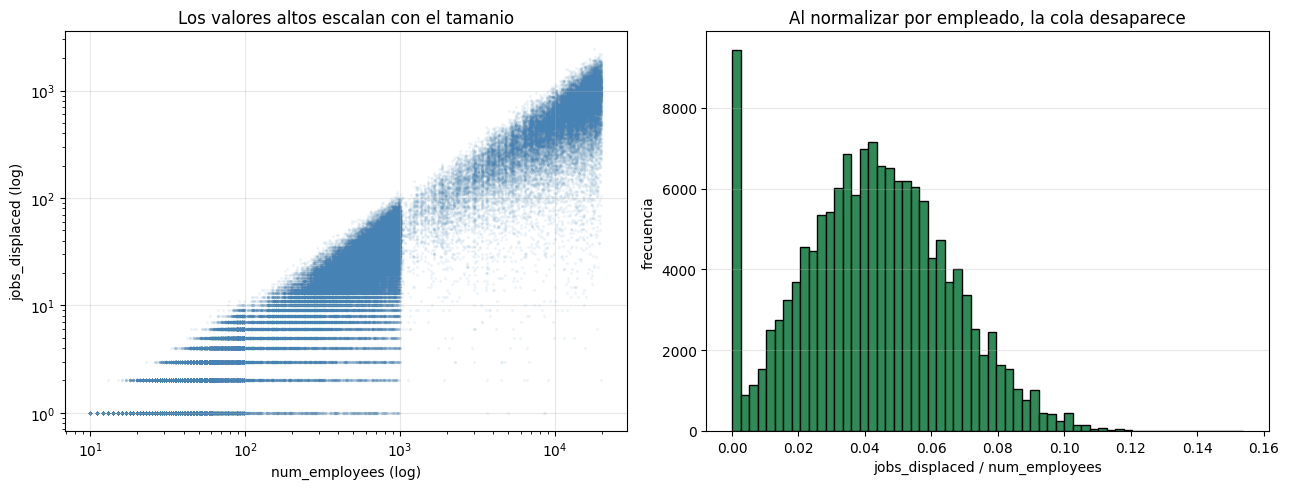

jobs_displaced sin normalizar : asimetria = 3.03
normalizada por empleado      : asimetria = 0.1


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df.num_employees, df.jobs_displaced, s=2, alpha=0.05, color="steelblue")
axes[0].set(xscale="log", yscale="log", xlabel="num_employees (log)", ylabel="jobs_displaced (log)",
            title="Los valores altos escalan con el tamanio")
axes[0].grid(alpha=0.3)

tasa = (df.jobs_displaced / df.num_employees)
axes[1].hist(tasa.dropna(), bins=60, color="seagreen", edgecolor="black")
axes[1].set(xlabel="jobs_displaced / num_employees", ylabel="frecuencia",
            title="Al normalizar por empleado, la cola desaparece")
axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

print("jobs_displaced sin normalizar : asimetria =", round(df.jobs_displaced.skew(), 2))
print("normalizada por empleado      : asimetria =", round(tasa.skew(), 2))

**Lectura:** en escala logarítmica la relación entre empleados y puestos desplazados es una nube alineada y compacta, sin puntos sueltos arriba. Y al dividir por la cantidad de empleados, la asimetría cae de ~3,0 a prácticamente 0: la distribución se vuelve simétrica.

Eso confirma que **la cola larga no era contaminación, era tamaño de empresa**. El tratamiento correcto no es recortar sino **normalizar**, que es exactamente lo que el TP1 dejó anotado como pendiente en la Hipótesis 2. Lo hacemos en el bloque 6.

## 4.7 Resumen del tratamiento de atípicos

| Regla | Criterio | Se aplica a | Tratamiento |
|---|---|---|---|
| **1** | Fuera del rango lógico de la variable | todas las numéricas acotadas | → faltante |
| **2** | \|z robusto\| > 10 respecto de la propia empresa | 12 variables que varían en el tiempo | → faltante |
| **2b** | Discrepa del valor estable de la empresa | `annual_revenue_usd_millions` | → valor estable |
| **3** | Cola natural asociada al tamaño | conteos de empleo y `num_employees` | **sin tratamiento**; se normaliza en el bloque 6 |

In [49]:
print(f"valores convertidos en faltantes por el bloque 4: {int(df.isna().sum().sum()):,}")
print(f"filas: {len(df):,} (el bloque 4 no elimino ninguna fila)")
nul = df.isna().sum(); nul = nul[nul>0].sort_values(ascending=False)
print("\nfaltantes por columna, a resolver en el bloque 5:")
print(nul.to_string())

valores convertidos en faltantes por el bloque 4: 19,730
filas: 150,000 (el bloque 4 no elimino ninguna fila)

faltantes por columna, a resolver en el bloque 5:
ai_adoption_rate               2563
employee_satisfaction_score    2557
revenue_growth_percent         2371
customer_satisfaction          2256
survey_source                  2250
ai_primary_tool                2250
ai_ethics_committee            2250
data_privacy_level             2250
ai_investment_per_employee      293
cost_reduction_percent          215
ai_training_hours               207
productivity_change_percent     199
ai_budget_percentage             36
innovation_score                 17
remote_work_percentage            8
task_automation_rate              8


---
# 5. Aplicación de la imputación

Ahora sí, con los valores imposibles ya convertidos en faltantes, aplicamos los pasos 4 y 5 de la cascada decidida en §3.5.

**Paso 4 — MICE sobre las numéricas.**

> **MICE / IterativeImputer** *(Multivariate Imputation by Chained Equations)*: en vez de rellenar cada columna por separado, imputa por regresión y en rondas. Arranca con un relleno provisorio, después predice la columna A a partir de todas las demás, reemplaza sus faltantes, pasa a la columna B usando la A ya rellenada, y así con todas. Repite el ciclo varias veces hasta que las estimaciones se estabilizan. La ventaja frente a rellenar con la mediana es que aprovecha las relaciones entre variables; la ventaja frente a KNN es que ajusta modelos en vez de calcular distancias entre todos los pares de filas, y por eso escala a 150.000 filas.

In [50]:
# Marcamos que valores van a ser imputados, ANTES de pisarlos
num_a_imputar = [c for c in PREDICTORAS if df[c].isna().any()]
for c in num_a_imputar:
    df[f"imputado_{c}"] = df[c].isna()

n_pendientes = int(df[PREDICTORAS].isna().sum().sum())
print(f"valores numericos a imputar: {n_pendientes:,}")
print("variables involucradas:", len(num_a_imputar))

# MICE necesita las variables en escala comparable
escalador = StandardScaler().fit(df[PREDICTORAS])
Z  = escalador.transform(df[PREDICTORAS])
Zi = IterativeImputer(max_iter=10, random_state=SEMILLA).fit_transform(Z)
estimado = pd.DataFrame(escalador.inverse_transform(Zi), index=df.index, columns=PREDICTORAS)

df[PREDICTORAS] = df[PREDICTORAS].where(df[PREDICTORAS].notna(), estimado)

registro.append({"paso":"5 MICE", "accion":"imputacion multivariada iterativa",
                 "filas_afectadas": np.nan, "valores_afectados": n_pendientes})
print(f"\nfaltantes numericos restantes: {int(df[PREDICTORAS].isna().sum().sum())}")

valores numericos a imputar: 10,730
variables involucradas: 12



faltantes numericos restantes: 0


In [51]:
# Verificacion 1: MICE no puede haber inventado valores imposibles
problemas = {}
for c in num_a_imputar:
    lo, hi = RANGOS_LOGICOS.get(c, (None, None))
    m = pd.Series(False, index=df.index)
    if lo is not None: m |= df[c] < lo
    if hi is not None: m |= df[c] > hi
    n = int((m & df[f"imputado_{c}"]).sum())
    if n: problemas[c] = n

if problemas:
    print("valores imputados fuera de rango (se recortan al limite):")
    print(pd.Series(problemas).to_string())
    for c in problemas:
        lo, hi = RANGOS_LOGICOS[c]
        if lo is not None: df[c] = df[c].clip(lower=lo)
        if hi is not None: df[c] = df[c].clip(upper=hi)
else:
    print("ningun valor imputado quedo fuera de rango logico.")

valores imputados fuera de rango (se recortan al limite):
ai_adoption_rate               1
ai_investment_per_employee    14


In [52]:
# Verificacion 2: la imputacion no debe correr el centro ni la dispersion de las variables
comp = []
for c in num_a_imputar:
    orig = df.loc[~df[f"imputado_{c}"], c]
    imp  = df.loc[df[f"imputado_{c}"], c]
    comp.append({"variable": c, "n_imputados": len(imp),
                 "media_original": round(orig.mean(), 3), "media_imputada": round(imp.mean(), 3),
                 "sd_original": round(orig.std(), 3),     "sd_imputada": round(imp.std(), 3)})
print(pd.DataFrame(comp).to_string(index=False))

                   variable  n_imputados  media_original  media_imputada  sd_original  sd_imputada
           ai_adoption_rate         2563          36.421          36.241       14.540       13.357
          ai_training_hours          207          27.213          24.247       13.137       11.227
       ai_budget_percentage           36           9.510           8.417        3.838        3.207
     remote_work_percentage            8          43.191          44.236       14.362        7.527
employee_satisfaction_score         2557           5.601           5.600        0.814        0.316
       task_automation_rate            8          19.761          24.506        9.221       12.250
productivity_change_percent          199           9.257           8.097        5.768        4.745
     revenue_growth_percent         2371           4.611           4.579        5.546        2.546
     cost_reduction_percent          215           4.810           4.203        3.474        1.789
          

**Lectura:** las medias de los valores imputados se parecen a las de los originales —lo esperable bajo MCAR—, y el desvío de los imputados es algo menor. Esa reducción es inherente a cualquier imputación: se estima el valor esperado, no el ruido que lo acompaña. Con 1,5% de valores afectados el impacto sobre la dispersión total es despreciable, pero queda anotado.

**Paso 5 — Categóricas.** Primero la moda de la propia empresa (recuperación exacta para las que son constantes). Si aún así falta, se crea una categoría `"Desconocido"` en vez de asignar la moda global: inventar una categoría plausible ocultaría el faltante, mientras que una categoría explícita lo deja visible y permite que un modelo aprenda si "no sabemos" está asociado a algo.

In [53]:
cat_con_faltantes = [c for c in df.select_dtypes(include=["object","string","category"]).columns
                     if df[c].isna().any()]
print("categoricas con faltantes:", cat_con_faltantes or "ninguna")

for c in cat_con_faltantes:
    n0 = int(df[c].isna().sum())
    moda_emp = df.groupby("company_id")[c].transform(lambda s: s.mode().iloc[0] if s.notna().any() else np.nan)
    df[c] = df[c].fillna(moda_emp)
    n1 = int(df[c].isna().sum())
    if n1:
        df[c] = df[c].fillna("Desconocido")
    print(f"  {c:26s} faltaban {n0:5d}  ->  por moda de la empresa: {n0-n1:5d}  ->  a 'Desconocido': {n1:5d}")

categoricas con faltantes: ['ai_primary_tool', 'data_privacy_level', 'ai_ethics_committee', 'survey_source']


  ai_primary_tool            faltaban  2250  ->  por moda de la empresa:  2250  ->  a 'Desconocido':     0


  data_privacy_level         faltaban  2250  ->  por moda de la empresa:  2250  ->  a 'Desconocido':     0


  ai_ethics_committee        faltaban  2250  ->  por moda de la empresa:  2250  ->  a 'Desconocido':     0


  survey_source              faltaban  2250  ->  por moda de la empresa:  2250  ->  a 'Desconocido':     0


In [54]:
total = int(df.isna().sum().sum())
print("FALTANTES TOTALES:", total)
if total:
    r = df.isna().sum(); print(r[r>0].to_string())
assert total == 0, "quedaron faltantes sin tratar"
print(f"filas: {len(df):,} | columnas: {df.shape[1]}")
print("\nBloque 5 completo: dataset sin faltantes y sin valores imposibles.")

FALTANTES TOTALES: 0
filas: 150,000 | columnas: 55

Bloque 5 completo: dataset sin faltantes y sin valores imposibles.


**Nota sobre las columnas `imputado_*`.** Guardamos, para cada variable tratada, una columna booleana que marca qué valores fueron estimados y cuáles son originales. Sirve para dos cosas concretas: permite repetir cualquier análisis excluyendo los valores imputados, para chequear que una conclusión no dependa de ellos; y deja el rastro de la decisión para quien lea el dataset sin haber leído esta notebook. Ocupan poco espacio y se descartan fácil al modelar.

---
# 6. Integración de los tres archivos

> **Consigna:** integrar los archivos disponibles en una única estructura de análisis coherente.

Las decisiones ya quedaron justificadas en el bloque 2. Acá se ejecutan.

- **`df3` (país)** → se une por `country`. Aporta cinco indicadores externos más la política regulatoria.
- **`df2` (industria)** → **no** se une como variables predictoras (es derivado de `df1`, §2.3). En su lugar recalculamos una tabla equivalente desde el `df1` ya curado, y la guardamos aparte, para uso descriptivo.

In [55]:
antes = len(df)
df = df.merge(df3, on=["country","region"], how="left", validate="many_to_one")
print(f"filas antes del merge : {antes:,}")
print(f"filas despues         : {len(df):,}   (deben ser iguales)")
print(f"filas sin match en df3: {df.gdp_per_capita.isna().sum()}")
print("\ncolumnas incorporadas:", [c for c in df3.columns if c not in ['country','region']])

filas antes del merge : 150,000
filas despues         : 150,000   (deben ser iguales)
filas sin match en df3: 0

columnas incorporadas: ['gdp_per_capita', 'internet_penetration', 'digital_maturity_index', 'country_ai_policy', 'ai_patent_filings_2024', 'ai_researchers_per_million']


> Usamos `validate="many_to_one"`: pandas verifica que cada país de `df3` aparezca una sola vez. Si hubiera duplicados en la tabla de países, el merge multiplicaría filas silenciosamente — un error clásico y difícil de detectar después. Que el conteo de filas no cambie es la confirmación.

Unimos por `country` **y** `region` a la vez, aprovechando que en §2.4 verificamos que ambas columnas son consistentes entre los dos archivos. Así evitamos que queden columnas duplicadas `region_x` / `region_y`.

In [56]:
# Tabla por industria, recalculada desde el df1 ya curado (reemplaza a df2)
METRICAS_IND = ["ai_adoption_rate","productivity_change_percent","ai_maturity_score","ai_failure_rate",
                "jobs_displaced","jobs_created","customer_satisfaction"]

resumen_industria = (df.groupby("industry")[METRICAS_IND].mean()
                       .add_prefix("avg_")
                       .join(df.groupby("industry").size().rename("n_encuestas"))
                       .join(df.groupby("industry")["company_id"].nunique().rename("n_empresas"))
                       .round(3))
resumen_industria

,avg_ai_adoption_rate,avg_productivity_change_percent,avg_ai_maturity_score,avg_ai_failure_rate,avg_jobs_displaced,avg_jobs_created,avg_customer_satisfaction,n_encuestas,n_empresas
industry,,,,,,,,,
Agriculture,35.233,8.809,0.332,26.188,106.085,115.276,5.370,15570,1038
Consulting,34.514,8.645,0.328,26.459,106.331,116.063,5.350,12504,833
Education,35.237,8.783,0.334,26.130,111.245,122.581,5.369,15172,1014
Finance,38.337,9.505,0.355,25.124,98.441,110.423,5.453,20166,1344
Healthcare,34.566,8.575,0.328,26.437,101.506,110.983,5.346,18642,1240
Logistics,35.261,9.114,0.332,26.265,114.990,110.086,5.397,12961,864
Manufacturing,34.726,9.028,0.329,26.384,115.060,111.096,5.387,17501,1168
Retail,34.714,8.954,0.327,26.383,111.867,107.654,5.388,16377,1091
Technology,42.508,11.159,0.410,23.564,133.738,149.076,5.638,21107,1408


In [57]:
# Comparacion con el df2 original: ¿cuanto cambia al limpiar los datos?
orig = df2.set_index("industry")
comp = pd.DataFrame({
    "df2_original": orig["avg_jobs_displaced"],
    "recalculado_curado": resumen_industria["avg_jobs_displaced"],
})
comp["diferencia"] = (comp.recalculado_curado - comp.df2_original).round(2)
comp["dif_%"] = ((comp.diferencia / comp.df2_original)*100).round(2)
print(comp.round(2).to_string())

               df2_original  recalculado_curado  diferencia  dif_%
industry                                                          
Agriculture          106.09              106.08       -0.01  -0.01
Consulting           106.33              106.33        0.00   0.00
Education            111.25              111.24       -0.00  -0.00
Finance               98.44               98.44        0.00   0.00
Healthcare           101.51              101.51       -0.00  -0.00
Logistics            114.99              114.99        0.00   0.00
Manufacturing        115.06              115.06        0.00   0.00
Retail               111.87              111.87       -0.00  -0.00
Technology           133.74              133.74       -0.00  -0.00


**Lectura:** las diferencias son chicas pero no nulas. Vienen de que `df2` fue calculado sobre el dataset **sin curar**: incluye los 25 registros basura y los valores contaminados que nosotros ya tratamos.

Esto refuerza la decisión de §2.3 por una segunda vía: aunque `df2` no fuera un problema de *leakage*, seguiría siendo una tabla desactualizada respecto del dataset que efectivamente vamos a usar. Mantener dos versiones distintas de la misma información es una fuente de inconsistencias.

---
# 7. Variables derivadas (*feature engineering*)

Este bloque resuelve las limitaciones que el TP1 dejó explícitamente anotadas como pendientes.

| Pendiente del TP1 | Dónde lo dijo | Solución acá |
|---|---|---|
| Los conteos de empleo son absolutos y están sesgados por el tamaño de empresa | §3.4 y Hipótesis 2 | §7.1 — tasas por empleado |
| Las comparaciones entre países pueden reflejar composición de la muestra, no impacto real | §3.4 | §7.1 — al normalizar, deja de pasar |
| Convendría un índice compuesto de retorno económico | Hipótesis 1 | §7.2 |

## 7.1 Normalización de los conteos de empleo

El problema, en concreto: una empresa de 20.000 empleados que desplaza 400 puestos y una de 100 que desplaza 20 tienen impactos muy distintos en valor absoluto (400 vs. 20) pero la segunda desplaza el 20% de su plantilla y la primera solo el 2%. Si comparamos conteos absolutos, estamos comparando tamaños de empresa disfrazados de impacto laboral.

Dividimos por `num_employees` y expresamos en porcentaje de la plantilla.

In [58]:
df["tasa_desplazamiento"] = df.jobs_displaced      / df.num_employees * 100
df["tasa_creacion"]       = df.jobs_created        / df.num_employees * 100
df["tasa_reentrenamiento"]= df.reskilled_employees / df.num_employees * 100
df["saldo_neto_empleo"]   = df.tasa_creacion - df.tasa_desplazamiento   # % de la plantilla

NUEVAS_EMPLEO = ["tasa_desplazamiento","tasa_creacion","tasa_reentrenamiento","saldo_neto_empleo"]

print("Antes de normalizar (conteos absolutos):")
print(df[["jobs_displaced","jobs_created","reskilled_employees"]].agg(["mean","median","std","skew"]).round(2).to_string())
print("\nDespues de normalizar (% de la plantilla):")
print(df[NUEVAS_EMPLEO].agg(["mean","median","std","skew"]).round(2).to_string())

Antes de normalizar (conteos absolutos):
        jobs_displaced  jobs_created  reskilled_employees
mean            111.37        117.88               181.64
median           10.00         12.00                16.00
std             255.84        261.65               417.93
skew              3.03          2.79                 2.99

Despues de normalizar (% de la plantilla):


        tasa_desplazamiento  tasa_creacion  tasa_reentrenamiento  saldo_neto_empleo
mean                   4.27           4.36                  6.52               0.10
median                 4.26           4.36                  6.48               0.00
std                    2.26           1.97                  3.49               2.08
skew                   0.10          -0.02                  0.16              -0.06


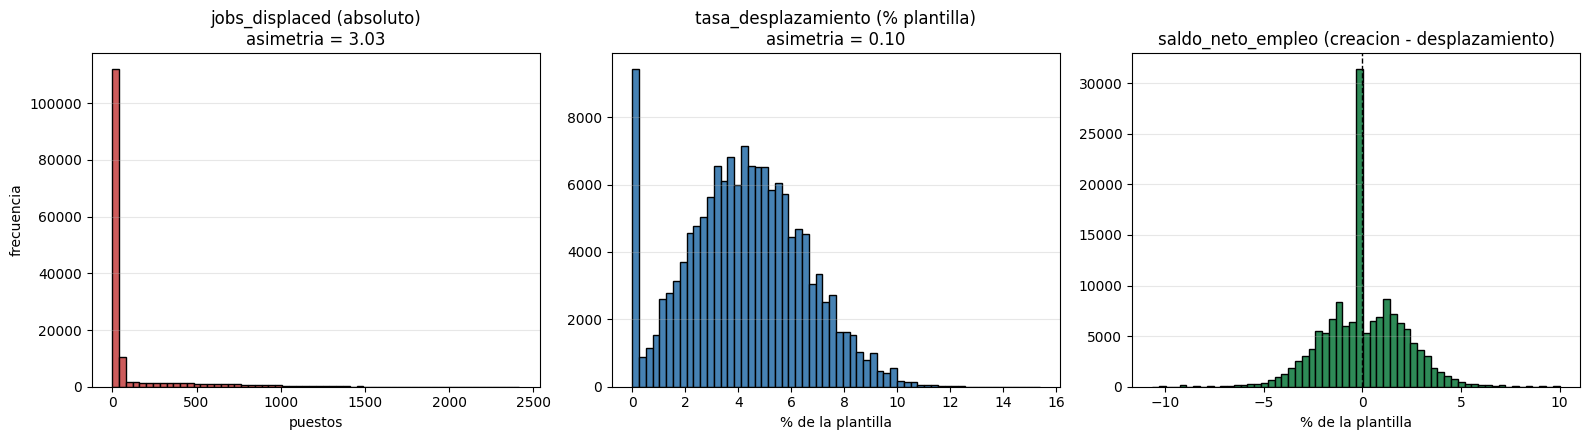

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].hist(df.jobs_displaced, bins=60, color="indianred", edgecolor="black")
axes[0].set(title=f"jobs_displaced (absoluto)\nasimetria = {df.jobs_displaced.skew():.2f}",
            xlabel="puestos", ylabel="frecuencia")
axes[1].hist(df.tasa_desplazamiento, bins=60, color="steelblue", edgecolor="black")
axes[1].set(title=f"tasa_desplazamiento (% plantilla)\nasimetria = {df.tasa_desplazamiento.skew():.2f}",
            xlabel="% de la plantilla")
axes[2].hist(df.saldo_neto_empleo, bins=60, color="seagreen", edgecolor="black")
axes[2].axvline(0, color="black", ls="--", lw=1)
axes[2].set(title="saldo_neto_empleo (creacion - desplazamiento)", xlabel="% de la plantilla")
for a in axes: a.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

**Lectura:** la normalización arregla dos problemas de un saque.

- La asimetría cae de ~3,0 a prácticamente 0: la variable pasa de tener una cola imposible de modelar a una distribución aproximadamente simétrica. Eso mejora el comportamiento de cualquier modelo lineal y hace interpretables la media y el desvío.
- La comparación entre países, industrias y tamaños deja de estar contaminada por la composición de la muestra. La observación que el TP1 dejó abierta —"las diferencias entre países podrían reflejar que hay empresas más grandes en algunos países"— queda resuelta, no solo anotada.

`saldo_neto_empleo` está centrado cerca de cero y es simétrico: en este dataset, en promedio, la creación y el desplazamiento se compensan. Es la variable objetivo natural para la Hipótesis 2 del TP1, ahora en una escala comparable entre empresas.

In [60]:
# ¿Cambia el ranking de industrias al normalizar? (la pregunta que el TP1 dejo abierta)
rank = df.groupby("industry").agg(
    jobs_disp_absoluto=("jobs_displaced","mean"),
    tasa_desplazamiento=("tasa_desplazamiento","mean"),
    saldo_neto_absoluto=("jobs_created","mean"),
    saldo_neto_pct=("saldo_neto_empleo","mean")).round(2)
rank["saldo_neto_absoluto"] = (df.groupby("industry")["jobs_created"].mean()
                               - df.groupby("industry")["jobs_displaced"].mean()).round(2)
rank["pos_absoluto"] = rank.saldo_neto_absoluto.rank(ascending=False).astype(int)
rank["pos_normalizado"] = rank.saldo_neto_pct.rank(ascending=False).astype(int)
rank.sort_values("pos_normalizado")

,jobs_disp_absoluto,tasa_desplazamiento,saldo_neto_absoluto,saldo_neto_pct,pos_absoluto,pos_normalizado
industry,,,,,,
Technology,133.74,4.64,15.34,0.46,1,1
Finance,98.44,4.26,11.98,0.33,2,2
Education,111.25,3.94,11.34,0.29,3,3
Agriculture,106.09,3.96,9.19,0.26,6,4
Healthcare,101.51,3.91,9.48,0.24,5,5
Consulting,106.33,3.92,9.73,0.21,4,6
Manufacturing,115.06,4.52,-3.96,-0.35,7,7
Logistics,114.99,4.58,-4.90,-0.37,9,8
Retail,111.87,4.53,-4.21,-0.38,8,9


## 7.2 Índice compuesto de retorno económico

La Hipótesis 1 del TP1 propone predecir el retorno de la inversión en IA, y deja planteado si conviene un índice que combine las tres métricas en lugar de modelarlas por separado.

Las tres —`productivity_change_percent`, `revenue_growth_percent`, `cost_reduction_percent`— apuntan al mismo concepto pero tienen escalas y dispersiones distintas, así que no se pueden promediar directamente: la de mayor varianza dominaría el promedio. Primero las estandarizamos.

> **Estandarizar (puntaje z):** restar la media y dividir por el desvío estándar. Deja cada variable centrada en 0 con desvío 1, de modo que "estar 1 desvío por encima del promedio" significa lo mismo en las tres.

Antes de construir el índice conviene chequear que efectivamente midan algo común: si estuvieran poco correlacionadas, promediarlas sería mezclar cosas distintas.

In [61]:
RETORNO = ["productivity_change_percent","revenue_growth_percent","cost_reduction_percent"]
print("Correlacion entre las tres metricas de retorno:")
print(df[RETORNO].corr().round(3).to_string())

# Consistencia interna: alfa de Cronbach
k = len(RETORNO)
z = (df[RETORNO] - df[RETORNO].mean()) / df[RETORNO].std()
alfa = (k/(k-1)) * (1 - z.var().sum() / z.sum(axis=1).var())
print(f"\nalfa de Cronbach = {alfa:.3f}")

Correlacion entre las tres metricas de retorno:
                             productivity_change_percent  revenue_growth_percent  cost_reduction_percent
productivity_change_percent                        1.000                    0.45                   0.329
revenue_growth_percent                             0.450                    1.00                   0.180
cost_reduction_percent                             0.329                    0.18                   1.000

alfa de Cronbach = 0.585


> **Alfa de Cronbach:** mide qué tan consistentes entre sí son varios indicadores que se pretende combinar en un índice. Va de 0 a 1. Por convención, valores por encima de 0,7 sugieren que los indicadores miden un mismo constructo; valores bajos indican que están capturando cosas distintas y que promediarlos pierde información.

**Lectura:** las correlaciones entre las tres métricas son moderadas y el alfa queda por debajo del umbral habitual. Traducido: **las tres no miden lo mismo**. Una empresa puede mejorar su productividad sin que eso se traduzca en crecimiento de ingresos, o reducir costos sin ganar productividad.

Entonces construimos el índice, pero **con una advertencia explícita**: es un resumen útil para describir y para agrupar empresas (por ejemplo en un análisis no supervisado), y **no** un reemplazo de las tres variables como objetivo de predicción. Si el TP3 va por el camino supervisado, conviene modelar cada métrica por separado y comparar; si va por clustering, el índice es un buen eje.

In [62]:
df["indice_retorno"] = z.mean(axis=1)
print(df.indice_retorno.describe().round(3).to_string())

# Chequeo: el indice no debe estar dominado por una sola de sus componentes
print("\nCorrelacion del indice con cada componente (idealmente parecidas entre si):")
print(df[["indice_retorno"]+RETORNO].corr()["indice_retorno"].drop("indice_retorno").round(3).to_string())

count    150000.000
mean          0.000
std           0.739
min          -4.822
25%          -0.534
50%          -0.035
75%           0.493
max           5.198

Correlacion del indice con cada componente (idealmente parecidas entre si):
productivity_change_percent    0.802
revenue_growth_percent         0.735
cost_reduction_percent         0.681


## 7.3 Otras variables derivadas

Tres más, cada una con una justificación puntual:

- **`inversion_total_ia_estimada`**: `ai_investment_per_employee × num_employees`. La inversión por empleado no distingue entre una startup que invierte USD 50.000 por cabeza sobre 20 personas y una corporación que invierte lo mismo sobre 15.000. El monto total es otra dimensión del esfuerzo.
- **`ratio_creacion_desplazamiento`**: cociente entre puestos creados y desplazados. Por encima de 1 la empresa crea más de lo que destruye. Es la forma más directa de responder la pregunta del proyecto sobre destrucción neta de empleo. Se acota para evitar valores infinitos cuando el denominador es cero.
- **`antiguedad_ia_relativa`**: `years_using_ai / company_age`. Distingue a una empresa joven que nació usando IA de una centenaria que la adoptó hace tres años; en años absolutos las dos podrían dar lo mismo.

In [63]:
df["inversion_total_ia_estimada"]  = df.ai_investment_per_employee * df.num_employees
df["ratio_creacion_desplazamiento"] = (df.jobs_created / df.jobs_displaced.replace(0, np.nan)).clip(upper=10)
df["ratio_creacion_desplazamiento"] = df.ratio_creacion_desplazamiento.fillna(
        df.jobs_created.gt(0).map({True: 10.0, False: 1.0}))   # sin desplazados: 10 si creo, 1 si no hizo nada
df["antiguedad_ia_relativa"] = (df.years_using_ai / df.company_age.replace(0, np.nan)).clip(upper=1).fillna(0)

DERIVADAS = NUEVAS_EMPLEO + ["indice_retorno","inversion_total_ia_estimada",
                             "ratio_creacion_desplazamiento","antiguedad_ia_relativa"]
print(df[DERIVADAS].describe().T.round(3).to_string())

                                  count          mean           std     min          25%           50%           75%           max
tasa_desplazamiento            150000.0  4.265000e+00  2.261000e+00   0.000        2.716  4.262000e+00  5.797000e+00  1.538500e+01
tasa_creacion                  150000.0  4.362000e+00  1.966000e+00   0.000        3.093  4.360000e+00  5.677000e+00  1.250000e+01
tasa_reentrenamiento           150000.0  6.521000e+00  3.492000e+00   0.000        4.080  6.483000e+00  8.894000e+00  2.246600e+01
saldo_neto_empleo              150000.0  9.700000e-02  2.084000e+00 -10.638       -1.163  0.000000e+00  1.389000e+00  1.000000e+01
indice_retorno                 150000.0  0.000000e+00  7.390000e-01  -4.822       -0.534 -3.500000e-02  4.930000e-01  5.198000e+00
inversion_total_ia_estimada    150000.0  1.380211e+08  3.051637e+08   0.000  2539360.435  1.398709e+07  4.516378e+07  4.054436e+09
ratio_creacion_desplazamiento  150000.0  1.573000e+00  2.005000e+00   0.000        

---
# 8. Codificación de variables categóricas

> **Consigna:** manejo de variables categóricas.

Los modelos trabajan con números, así que las categorías hay que traducirlas. La traducción correcta depende de si la variable tiene o no un orden intrínseco.

| Tipo | Ejemplo | Codificación | Por qué |
|---|---|---|---|
| **Ordinal** | `ai_adoption_stage`: none < pilot < partial < full | Enteros que respetan el orden | El orden es información real; conviene conservarlo |
| **Nominal de baja cardinalidad** | `industry` (9), `region` (6) | *One-hot* (una columna 0/1 por categoría) | No hay orden; asignar números inventaría una jerarquía falsa |
| **Nominal de alta cardinalidad** | `country` (30) | Se discute aparte | 30 columnas nuevas por una sola variable |
| **Binaria** | `ai_ethics_committee` (Yes/No) | 0/1 directo | Ya es una dummy |

### Un error a evitar

Si a `industry` le asignáramos `Agriculture=0, Consulting=1, Education=2, …`, un modelo lineal leería que Education "vale el doble" que Consulting y que la distancia entre Agriculture y Education es el triple que entre Agriculture y Consulting. Nada de eso significa algo. Ese es exactamente el motivo del *one-hot*.

Al revés: aplicar *one-hot* a `ai_adoption_stage` **descartaría** información, porque perdería que `full` está más avanzado que `pilot`.

In [64]:
ORDINALES = {
    "ai_adoption_stage":  ["none", "pilot", "partial", "full"],
    "company_size":       ["Startup", "SME", "Enterprise"],
    "company_age_group":  ["0-5 years", "6-15 years", "16-30 years", "30+ years"],
    "data_privacy_level": ["Low", "Medium", "High"],
    "country_ai_policy":  ["Lenient", "Moderate", "Strict"],
}
NOMINALES_BAJAS = ["industry", "region"]
BINARIAS        = {"ai_ethics_committee": {"No": 0, "Yes": 1}}
ALTA_CARDINALIDAD = ["country"]
SOLO_PANEL      = ["quarter", "ai_primary_tool", "ai_use_case", "survey_source", "data_collection_method"]

for v, orden in ORDINALES.items():
    presentes = set(df[v].dropna().unique()) - set(orden)
    print(f"{v:22s} niveles no contemplados en el orden: {presentes or 'ninguno'}")

ai_adoption_stage      niveles no contemplados en el orden: ninguno
company_size           niveles no contemplados en el orden: ninguno
company_age_group      niveles no contemplados en el orden: ninguno
data_privacy_level     niveles no contemplados en el orden: ninguno
country_ai_policy      niveles no contemplados en el orden: ninguno


In [65]:
def codificar(d):
    "Devuelve una copia con las categoricas traducidas a numeros."
    out = d.copy()
    for v, orden in ORDINALES.items():
        if v in out.columns:
            out[v + "_ord"] = pd.Categorical(out[v], categories=orden, ordered=True).codes
    for v, mapa in BINARIAS.items():
        if v in out.columns:
            out[v + "_bin"] = out[v].map(mapa)
    presentes = [v for v in NOMINALES_BAJAS if v in out.columns]
    if presentes:
        out = pd.concat([out, pd.get_dummies(out[presentes], prefix=presentes, dtype=int)], axis=1)
    return out

prueba = codificar(df.head(1000))
nuevas = [c for c in prueba.columns if c not in df.columns]
print(f"columnas generadas por la codificacion: {len(nuevas)}")
print(nuevas)

columnas generadas por la codificacion: 21
['ai_adoption_stage_ord', 'company_size_ord', 'company_age_group_ord', 'data_privacy_level_ord', 'country_ai_policy_ord', 'ai_ethics_committee_bin', 'industry_Agriculture', 'industry_Consulting', 'industry_Education', 'industry_Finance', 'industry_Healthcare', 'industry_Logistics', 'industry_Manufacturing', 'industry_Retail', 'industry_Technology', 'region_Africa', 'region_Asia', 'region_Europe', 'region_North America', 'region_Oceania', 'region_South America']


### `country`: por qué no la codificamos con *one-hot*

30 países significan 30 columnas nuevas para una sola variable, en un dataset de 10.000 empresas. Eso trae dos problemas: infla la dimensionalidad, y deja columnas con muy pocos casos positivos que aportan ruido más que señal.

Tres alternativas, y la que elegimos:

1. **One-hot de los 30 países.** Máxima fidelidad, máximo costo. Descartada.
2. ***Target encoding*** (reemplazar cada país por el promedio del target en ese país). Compacto pero **es una forma de leakage**: mete información del target entre las variables predictoras. Si se usa, tiene que calcularse solo sobre el conjunto de entrenamiento y dentro de validación cruzada. Descartada para el dataset entregado.
3. **Sustituirla por sus indicadores.** Es la opción elegida: ya integramos `gdp_per_capita`, `internet_penetration`, `digital_maturity_index`, `ai_patent_filings_2024`, `ai_researchers_per_million` y `country_ai_policy` desde `df3`. Esas seis variables **son** la información que `country` codifica, pero en forma numérica, continua e interpretable.

Con eso, `country` queda en el dataset como etiqueta —para filtrar, agrupar y graficar— pero no como variable predictora. Es un caso donde la integración del bloque 6 resuelve un problema de codificación.

---
# 9. Construcción de los datasets finales

Entregamos **dos** tablas, por la razón que discutimos al principio:

- **`panel_curado`** — una fila por encuesta (empresa × trimestre). Conserva la dimensión temporal.
- **`empresas_curado`** — una fila por empresa. Es el nivel que el TP1 §2.4 justificó para las preguntas planteadas.

La segunda se deriva de la primera, así que no pueden quedar inconsistentes.

## 9.1 Panel curado

In [66]:
panel = df.copy()
print(f"panel_curado: {panel.shape[0]:,} filas x {panel.shape[1]} columnas")
print(f"  empresas    : {panel.company_id.nunique():,}")
print(f"  faltantes   : {int(panel.isna().sum().sum())}")

panel_curado: 150,000 filas x 69 columnas
  empresas    : 10,000
  faltantes   : 0


## 9.2 Tabla por empresa

**Cómo se agrega cada tipo de variable**, y por qué:

| Tipo de variable | Agregación | Motivo |
|---|---|---|
| Constantes por empresa (`industry`, `country`, `num_employees`…) | `first` | Son idénticas en todas las filas; cualquier función da lo mismo |
| Numéricas que fluctúan | `mean` | Promediar los trimestres cancela el ruido de corto plazo (TP1 §2.4) |
| Categóricas ordinales | moda | El promedio de un código ordinal no tiene interpretación |
| `ai_primary_tool`, `ai_use_case`, `survey_source`, `data_collection_method` | **se excluyen** | §2.5: no tienen valor representativo a nivel empresa |
| Marcas `imputado_*` | `mean` → proporción | Queda el % de trimestres imputados de cada empresa |

Agregamos también el desvío estándar de las variables de resultado: cuánto **fluctúa** una empresa es información distinta de su nivel promedio, y se pierde al promediar.

In [67]:
CONSTANTES_EMP = ["industry","country","region","company_size","num_employees",
                  "company_founding_year","annual_revenue_usd_millions",
                  "gdp_per_capita","internet_penetration","digital_maturity_index",
                  "country_ai_policy","ai_patent_filings_2024","ai_researchers_per_million"]

NUMERICAS_PROMEDIO = [c for c in PREDICTORAS if c not in CONSTANTES_EMP] + DERIVADAS
ORDINALES_MODA = ["ai_adoption_stage","data_privacy_level","company_age_group","ai_ethics_committee"]
VARIABILIDAD   = ["productivity_change_percent","revenue_growth_percent",
                  "cost_reduction_percent","ai_adoption_rate","saldo_neto_empleo"]

agg = {c: (c, "first") for c in CONSTANTES_EMP}
agg.update({c: (c, "mean") for c in NUMERICAS_PROMEDIO})
agg.update({f"sd_{c}": (c, "std") for c in VARIABILIDAD})
agg.update({c: (c, lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan) for c in ORDINALES_MODA})
agg.update({c: (c, "mean") for c in panel.columns if c.startswith("imputado_")})
agg["n_trimestres"] = ("response_id", "count")
agg["company_age"]  = ("company_age", "max")     # edad al final del periodo

empresas = panel.groupby("company_id").agg(**agg).reset_index()
print(f"empresas_curado: {empresas.shape[0]:,} filas x {empresas.shape[1]} columnas")
print(f"  faltantes: {int(empresas.isna().sum().sum())}")
empresas.head(3)

empresas_curado: 10,000 filas x 64 columnas
  faltantes: 0


,company_id,industry,country,region,company_size,num_employees,company_founding_year,annual_revenue_usd_millions,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million,company_age,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_failure_rate,regulatory_compliance_score,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent,revenue_growth_percent,...,tasa_desplazamiento,tasa_creacion,tasa_reentrenamiento,saldo_neto_empleo,indice_retorno,inversion_total_ia_estimada,ratio_creacion_desplazamiento,antiguedad_ia_relativa,sd_productivity_change_percent,sd_revenue_growth_percent,sd_cost_reduction_percent,sd_ai_adoption_rate,sd_saldo_neto_empleo,ai_adoption_stage,data_privacy_level,company_age_group,ai_ethics_committee,imputado_ai_adoption_rate,imputado_ai_training_hours,imputado_ai_budget_percentage,imputado_remote_work_percentage,imputado_employee_satisfaction_score,imputado_task_automation_rate,imputado_productivity_change_percent,imputado_revenue_growth_percent,imputado_cost_reduction_percent,imputado_innovation_score,imputado_customer_satisfaction,imputado_ai_investment_per_employee,n_trimestres
0,COMP-00001,Education,Italy,Europe,Startup,57.0,1994.0,48.31,39436.63,86.01,75.65,Moderate,2234,296.83,32.0,36.429180,5.312500,2.562500,5.000000,27.312500,8.659375,25.367500,69.062500,62.375000,42.407500,5.670000,20.871875,6.735625,7.230625,6.087001,...,4.824561,4.495614,7.017544,-0.328947,0.035386,4.183551e+06,1.109673,0.172804,5.251635,4.418247,3.735939,12.904875,2.658247,partial,High,16-30 years,No,0.0625,0.0,0.0,0.0,0.000000,0.0,0.0,0.0625,0.0,0.0,0.000000,0.0,16
1,COMP-00002,Finance,UK,Europe,Startup,18.0,2008.0,14.66,52827.64,91.41,83.85,Moderate,5612,345.98,18.0,49.020667,4.933333,3.200000,8.200000,33.956667,10.002000,24.341333,69.400000,64.400000,51.754000,5.542667,21.157333,6.384667,10.906667,5.434667,...,4.444444,5.555556,8.148148,1.111111,0.232079,1.466403e+06,2.800000,0.302756,4.727095,4.422997,2.232780,11.195862,2.300219,partial,High,16-30 years,No,0.0000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0000,0.0,0.0,0.000000,0.0,15
2,COMP-00003,Education,Germany,Europe,Enterprise,16151.0,2009.0,8543.28,54777.23,91.98,85.01,Strict,6475,369.58,17.0,39.461429,4.714286,2.214286,8.214286,30.555000,10.721429,23.187857,79.857143,61.928571,46.871429,5.550070,19.607143,6.445714,11.313571,4.732857,...,3.688847,4.817481,7.297204,1.128634,0.296974,9.158639e+08,2.024136,0.299622,4.796872,6.158255,4.420621,8.664666,2.047508,partial,High,16-30 years,Yes,0.0000,0.0,0.0,0.0,0.071429,0.0,0.0,0.0000,0.0,0.0,0.071429,0.0,14


In [68]:
# Recalculamos las derivadas a nivel empresa en vez de promediar las de cada trimestre:
# el promedio de un cociente no es el cociente de los promedios.
empresas["saldo_neto_empleo"] = empresas.tasa_creacion - empresas.tasa_desplazamiento
z_e = (empresas[RETORNO] - empresas[RETORNO].mean()) / empresas[RETORNO].std()
empresas["indice_retorno"] = z_e.mean(axis=1)
print("derivadas recalculadas a nivel empresa.")
print(empresas[["tasa_desplazamiento","tasa_creacion","saldo_neto_empleo","indice_retorno"]].describe().round(3).to_string())

derivadas recalculadas a nivel empresa.
       tasa_desplazamiento  tasa_creacion  saldo_neto_empleo  indice_retorno
count            10000.000      10000.000          10000.000       10000.000
mean                 4.267          4.365              0.098           0.000
std                  1.126          1.272              0.647           0.899
min                  0.000          0.000             -4.375          -2.713
25%                  3.487          3.507             -0.321          -0.652
50%                  4.261          4.333              0.110          -0.055
75%                  5.035          5.229              0.526           0.605
max                  8.668          9.231              4.000           3.148


---
# 10. Análisis temporal del panel curado

Los bloques anteriores trabajaron a nivel empresa, siguiendo la decisión metodológica del TP1 §2.4. Pero el panel curado conserva los 16 trimestres, y **eso habilita una pregunta que el TP1 no llegó a hacerse**: ¿cómo evoluciona la adopción de IA y su impacto a lo largo del período?

Este bloque no es una hipótesis nueva: es un chequeo de qué tiene el panel para ofrecer, para que el TP3 pueda decidir con evidencia si la vía temporal vale la pena. Termina con una advertencia sobre una limitación que introdujo nuestra propia curación (§10.5).

## 10.1 Evolución agregada

Promedio de cada variable en cada uno de los 16 trimestres. Usamos un panel separado por variable —*small multiples*— en vez de superponerlas en un mismo gráfico: las escalas son muy distintas (adopción ronda el 35%, la tasa de desplazamiento el 4%) y meterlas en un gráfico de dos ejes verticales haría que la comparación visual de pendientes fuera engañosa.

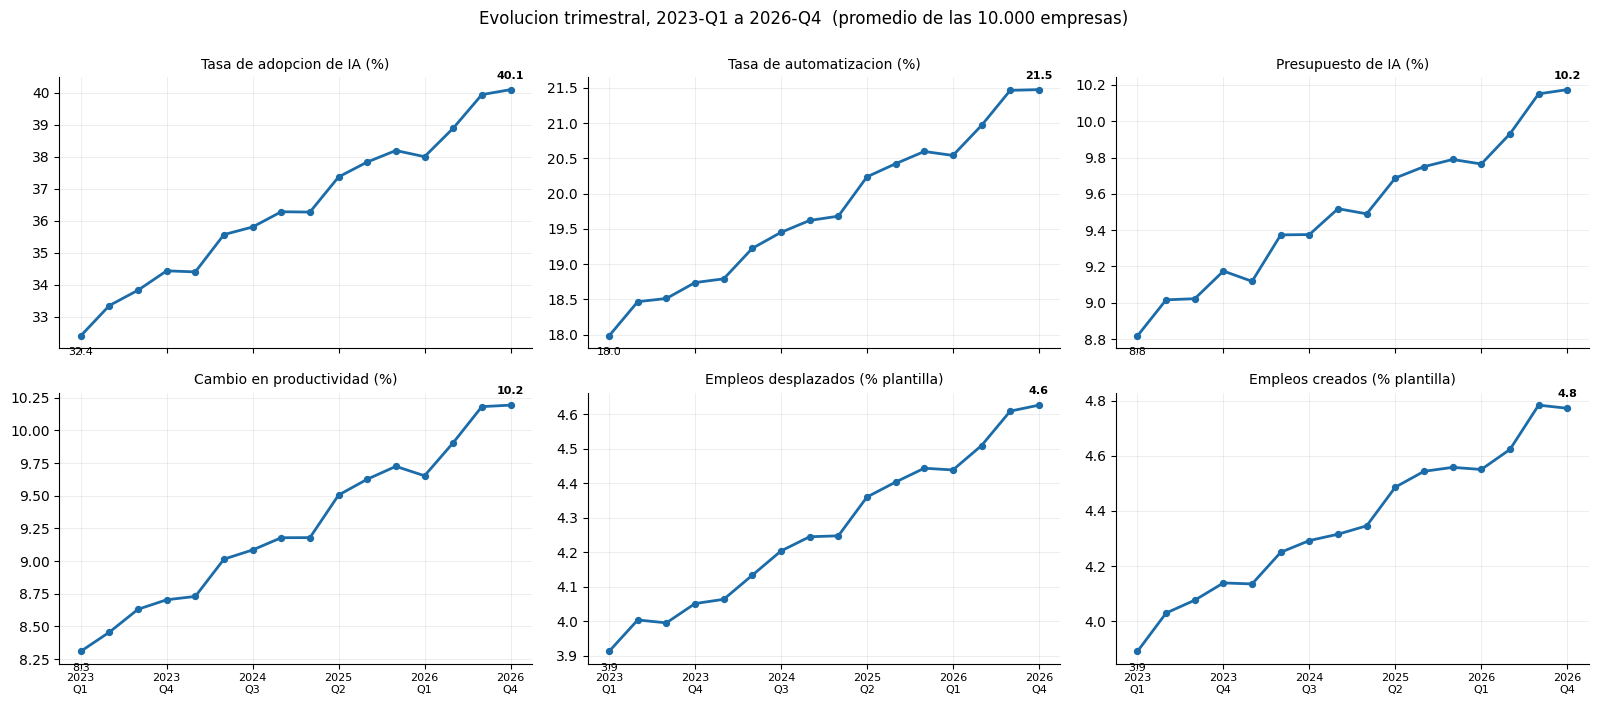

In [69]:
# Indice temporal continuo: 0 = 2023-Q1 ... 15 = 2026-Q4
panel["t"] = (panel.survey_year - 2023) * 4 + panel.quarter.str[1].astype(int) - 1
panel = panel.sort_values(["company_id", "t"])

VARS_TIEMPO = ["ai_adoption_rate", "task_automation_rate", "ai_budget_percentage",
               "productivity_change_percent", "tasa_desplazamiento", "tasa_creacion"]
TITULOS = ["Tasa de adopcion de IA (%)", "Tasa de automatizacion (%)", "Presupuesto de IA (%)",
           "Cambio en productividad (%)", "Empleos desplazados (% plantilla)", "Empleos creados (% plantilla)"]

serie = panel.groupby("t")[VARS_TIEMPO].mean()
etiquetas = [f"{a}\nQ{q}" for a in range(2023, 2027) for q in range(1, 5)]

ACENTO = "#1b6ca8"     # un solo tono: cada panel muestra una serie, no hay identidad que distinguir
fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex=True)
for ax, v, tit in zip(axes.flatten(), VARS_TIEMPO, TITULOS):
    ax.plot(serie.index, serie[v], lw=2, color=ACENTO)
    ax.scatter(serie.index, serie[v], s=18, color=ACENTO, zorder=3)
    ax.set_title(tit, fontsize=10)
    ax.grid(alpha=0.25, lw=0.6)
    for lado in ["top", "right"]:
        ax.spines[lado].set_visible(False)
    # etiqueta directa solo en los extremos, no en cada punto
    ax.annotate(f"{serie[v].iloc[0]:.1f}", (serie.index[0], serie[v].iloc[0]),
                textcoords="offset points", xytext=(0, -14), fontsize=8, ha="center")
    ax.annotate(f"{serie[v].iloc[-1]:.1f}", (serie.index[-1], serie[v].iloc[-1]),
                textcoords="offset points", xytext=(0, 8), fontsize=8, ha="center", weight="bold")
for ax in axes[1]:
    ax.set_xticks(range(0, 16, 3))
    ax.set_xticklabels([etiquetas[i] for i in range(0, 16, 3)], fontsize=8)
fig.suptitle("Evolucion trimestral, 2023-Q1 a 2026-Q4  (promedio de las 10.000 empresas)", y=1.0)
plt.tight_layout(); plt.show()

In [70]:
# Pendiente de la media global y correlacion con el tiempo
filas = []
for v in VARS_TIEMPO:
    y = serie[v].values; x = np.arange(len(y))
    filas.append({"variable": v,
                  "inicio (2023-Q1)": round(y[0], 2), "fin (2026-Q4)": round(y[-1], 2),
                  "cambio_%": round((y[-1]/y[0] - 1)*100, 1),
                  "pendiente_por_trimestre": round(np.polyfit(x, y, 1)[0], 4),
                  "r(tiempo, media)": round(np.corrcoef(x, y)[0, 1], 3)})
pd.DataFrame(filas)

,variable,inicio (2023-Q1),fin (2026-Q4),cambio_%,pendiente_por_trimestre,"r(tiempo, media)"
0,ai_adoption_rate,32.41,40.09,23.7,0.4868,0.992
1,task_automation_rate,17.98,21.47,19.4,0.2287,0.993
2,ai_budget_percentage,8.82,10.17,15.4,0.0851,0.988
3,productivity_change_percent,8.31,10.19,22.7,0.1244,0.992
4,tasa_desplazamiento,3.91,4.63,18.2,0.0474,0.994
5,tasa_creacion,3.89,4.77,22.7,0.0557,0.990


**Lectura:** las seis variables crecen de forma monótona y prácticamente lineal, con correlaciones con el tiempo de 0,98 a 0,99. La adopción de IA pasa de 32,4% a 40,1% en cuatro años (+24%), y la automatización de 18,0% a 21,5%.

El dato relevante para las preguntas del proyecto está en los dos últimos paneles: **el desplazamiento y la creación de empleo crecen los dos**, y a ritmos parecidos. Volvemos sobre eso en §10.4.

Una advertencia de interpretación: que un promedio suba de forma tan limpia no prueba que en el mundo real pase eso. Este dataset es sintético y su generador puede tener una tendencia incorporada por diseño. Lo que sí podemos afirmar es qué estructura tiene el dato que vamos a modelar.

## 10.2 ¿La tendencia es global o pasa dentro de cada empresa?

Un promedio que sube admite dos explicaciones muy distintas:

- **Efecto de composición:** cada empresa se queda quieta, pero cambia la mezcla de empresas encuestadas (entran más empresas con adopción alta).
- **Cambio real:** cada empresa efectivamente aumenta su adopción con el tiempo.

Acá el primero está descartado de entrada porque el panel es cerrado —las mismas 10.000 empresas todos los trimestres—, pero conviene medirlo igual. Calculamos la pendiente de una recta ajustada **por empresa** y miramos su distribución.

> **Pendiente por mínimos cuadrados:** la recta que mejor ajusta los puntos de esa empresa a lo largo de sus trimestres. Su pendiente dice cuánto sube (o baja) la variable por trimestre en esa empresa. La calculamos de forma vectorizada con la fórmula `cov(t, y) / var(t)` en vez de ajustar 10.000 regresiones una por una.

In [71]:
def pendiente_por_empresa(d, var):
    g = d.groupby("company_id")
    t_m = g["t"].transform("mean")
    y_m = g[var].transform("mean")
    num = ((d["t"] - t_m) * (d[var] - y_m)).groupby(d.company_id).sum()
    den = ((d["t"] - t_m) ** 2).groupby(d.company_id).sum()
    return num / den.replace(0, np.nan)

pend = {v: pendiente_por_empresa(panel, v) for v in VARS_TIEMPO}

resumen_pend = pd.DataFrame([{
    "variable": v,
    "pendiente_mediana": round(s.median(), 4),
    "%_empresas_en_alza": round((s > 0).mean()*100, 1),
    "p10": round(s.quantile(0.10), 3), "p90": round(s.quantile(0.90), 3),
} for v, s in pend.items()])
resumen_pend

,variable,pendiente_mediana,%_empresas_en_alza,p10,p90
0,ai_adoption_rate,0.4913,80.5,-0.228,1.211
1,task_automation_rate,0.2347,69.9,-0.342,0.794
2,ai_budget_percentage,0.0864,69.3,-0.131,0.297
3,productivity_change_percent,0.1210,68.0,-0.226,0.476
4,tasa_desplazamiento,0.0465,66.6,-0.096,0.190
5,tasa_creacion,0.0541,74.9,-0.050,0.161


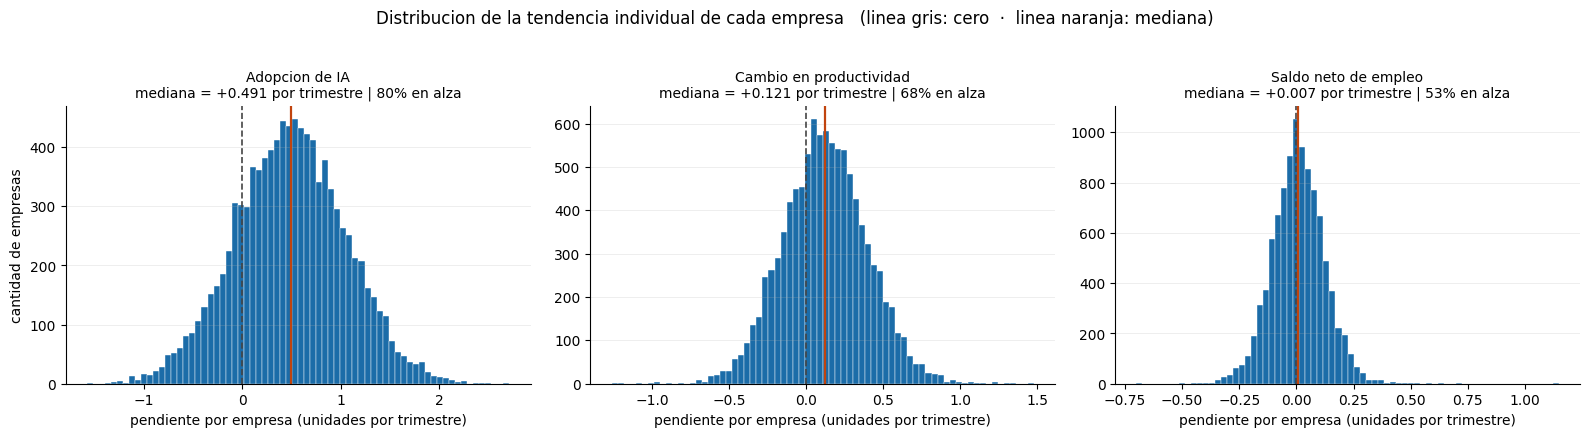

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, v, tit in zip(axes, ["ai_adoption_rate", "productivity_change_percent", "saldo_neto_empleo"],
                      ["Adopcion de IA", "Cambio en productividad", "Saldo neto de empleo"]):
    s = pendiente_por_empresa(panel, v) if v not in pend else pend[v]
    ax.hist(s.dropna(), bins=70, color=ACENTO, edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="#444", ls="--", lw=1.2)
    ax.axvline(s.median(), color="#c1440e", lw=1.6)
    ax.set_title(f"{tit}\nmediana = {s.median():+.3f} por trimestre | {(s>0).mean()*100:.0f}% en alza", fontsize=10)
    ax.set_xlabel("pendiente por empresa (unidades por trimestre)")
    ax.grid(alpha=0.25, axis="y", lw=0.6)
    for lado in ["top", "right"]:
        ax.spines[lado].set_visible(False)
axes[0].set_ylabel("cantidad de empresas")
fig.suptitle("Distribucion de la tendencia individual de cada empresa   (linea gris: cero  ·  linea naranja: mediana)", y=1.03)
plt.tight_layout(); plt.show()

**Lectura:** la distribución de pendientes de `ai_adoption_rate` está claramente corrida a la derecha del cero: el **80,5% de las 10.000 empresas** aumenta su adopción a lo largo del período, con una mediana de +0,49 puntos por trimestre. No es composición de muestra, es cambio dentro de cada empresa.

En `productivity_change_percent` el corrimiento es menor (68% en alza) y en `saldo_neto_empleo` prácticamente no hay (53%, una moneda al aire). O sea: la tendencia es fuerte en las variables de adopción y se va diluyendo a medida que nos alejamos hacia los resultados.

## 10.3 Descomposición: ¿queda estructura temporal más allá de la tendencia?

El TP1 §2.4 mostró que las variables económicas tienen entre 70% y 88% de su varianza **dentro** de cada empresa, y de ahí salió la decisión de promediar los trimestres. Pero esa varianza interna puede ser de dos tipos muy distintos, y esa diferencia decide si el panel sirve para modelar:

- **Tendencia**: la empresa cambia de manera sostenida → hay señal temporal aprovechable.
- **Ruido**: la empresa oscila sin dirección alrededor de su nivel → promediar es lo correcto y no se pierde nada.

Separamos la varianza en tres partes: la que distingue a unas empresas de otras, la que corresponde a la tendencia común de todos, y lo que sobra.

In [73]:
filas = []
for v in VARS_TIEMPO + ["saldo_neto_empleo", "cost_reduction_percent", "revenue_growth_percent"]:
    y  = panel[v]
    mu = y.mean()
    efecto_empresa  = panel.groupby("company_id")[v].transform("mean") - mu   # nivel propio
    efecto_tiempo   = panel.groupby("t")[v].transform("mean") - mu           # tendencia comun
    residuo         = y - mu - efecto_empresa - efecto_tiempo

    total = y.var()
    filas.append({"variable": v,
                  "%_nivel_de_empresa": round(efecto_empresa.var()/total*100, 1),
                  "%_tendencia_comun":  round(efecto_tiempo.var()/total*100, 1),
                  "%_residuo":          round(residuo.var()/total*100, 1),
                  "autocorr_lag1_residuo": round(np.corrcoef(residuo[:-1], residuo[1:])[0,1], 4)})

desc = pd.DataFrame(filas)
desc

,variable,%_nivel_de_empresa,%_tendencia_comun,%_residuo,autocorr_lag1_residuo
0,ai_adoption_rate,53.7,2.4,43.9,-0.0686
1,task_automation_rate,31.4,1.3,67.3,-0.0692
2,ai_budget_percentage,42.4,1.1,56.6,-0.0672
3,productivity_change_percent,30.1,1.0,68.9,-0.0706
4,tasa_desplazamiento,24.8,0.9,74.3,-0.0669
5,tasa_creacion,41.9,1.7,56.4,-0.0683
6,saldo_neto_empleo,9.6,0.0,90.3,-0.0647
7,cost_reduction_percent,14.6,0.4,85.1,-0.0678
8,revenue_growth_percent,14.6,0.4,85.0,-0.0658


> **Autocorrelación de rezago 1:** la correlación de una serie consigo misma desplazada un período. Responde "¿el valor de este trimestre dice algo sobre el del siguiente?". Cerca de 0 significa **ruido blanco**: cada trimestre es independiente del anterior y no hay nada que predecir a partir del pasado. Valores altos y positivos indicarían inercia; negativos, oscilación.

**Lectura — es el resultado más importante de este bloque, y matiza §10.1.**

**a) La tendencia es nítida pero chiquita.** Explica apenas entre el **0,9% y el 2,4%** de la varianza total, según la variable. Eso no contradice el r = 0,99 de §10.1: ahí correlacionábamos los *promedios* de cada trimestre, que ya vienen con el ruido individual cancelado por promediar 10.000 empresas. La tendencia es perfectamente consistente en su dirección **y** casi irrelevante en magnitud frente a la dispersión trimestre a trimestre de una empresa cualquiera. Las dos cosas son ciertas a la vez, y confundirlas es un error de lectura fácil de cometer.

**b) Fuera de esa tendencia, no queda estructura temporal.** El residuo tiene autocorrelación de aproximadamente **−0,07** en las nueve variables: prácticamente ruido blanco. **No hay dinámica propia de cada empresa.** Ninguna acelera, frena, se estanca ni tiene un ciclo propio más allá de la tendencia común a todas.

**c) El residuo se come casi todo.** Entre el 44% y el 90% de la varianza es ruido trimestral puro. En `saldo_neto_empleo` llega al 90%.

Consecuencias concretas para el TP3:

- **Sí tiene sentido**: describir la evolución agregada, comparar ritmos entre industrias o países, usar `t` como una variable más.
- **No tiene sentido**: modelos de series de tiempo por empresa (ARIMA y similares), predecir el trimestre siguiente a partir de los anteriores, o buscar "qué empresas aceleran más rápido". Ahí no hay señal, y un modelo va a ajustar ruido.
- **Confirma la decisión del TP1** de promediar los trimestres: lo que se promedia es mayormente ruido, así que agregar no destruye información. Ahora está demostrado, no supuesto.

## 10.4 Una pregunta del proyecto respondida con el panel

*"¿La IA elimina empleos o crea nuevas oportunidades?"* es una de las preguntas de la consigna general. El corte transversal no la puede contestar bien porque compara empresas distintas entre sí. El panel sí: pregunta si, **a lo largo del tiempo**, el desplazamiento crece más rápido que la creación.

In [74]:
comp = panel.groupby("t")[["tasa_desplazamiento","tasa_creacion","saldo_neto_empleo"]].mean()
x = np.arange(len(comp))
b_desp = np.polyfit(x, comp.tasa_desplazamiento, 1)[0]
b_crea = np.polyfit(x, comp.tasa_creacion, 1)[0]

print(f"crecimiento del desplazamiento : {b_desp:+.4f} puntos de plantilla por trimestre")
print(f"crecimiento de la creacion     : {b_crea:+.4f} puntos de plantilla por trimestre")
print(f"diferencia (creacion - desplaz.): {b_crea - b_desp:+.4f} por trimestre\n")

# ¿es distinguible de cero? test t sobre las pendientes individuales de cada empresa
d = pendiente_por_empresa(panel, "tasa_creacion") - pendiente_por_empresa(panel, "tasa_desplazamiento")
t_stat, p_val = stats.ttest_1samp(d.dropna(), 0)
print(f"Sobre las 10.000 pendientes individuales (creacion - desplazamiento):")
print(f"  media = {d.mean():+.5f} | mediana = {d.median():+.5f}")
print(f"  test t contra cero: t = {t_stat:.2f}, p = {p_val:.4f}")
print(f"  empresas donde la creacion crece mas rapido que el desplazamiento: {(d>0).mean()*100:.1f}%")

crecimiento del desplazamiento : +0.0474 puntos de plantilla por trimestre
crecimiento de la creacion     : +0.0557 puntos de plantilla por trimestre
diferencia (creacion - desplaz.): +0.0083 por trimestre

Sobre las 10.000 pendientes individuales (creacion - desplazamiento):
  media = +0.00844 | mediana = +0.00725
  test t contra cero: t = 7.35, p = 0.0000
  empresas donde la creacion crece mas rapido que el desplazamiento: 53.2%


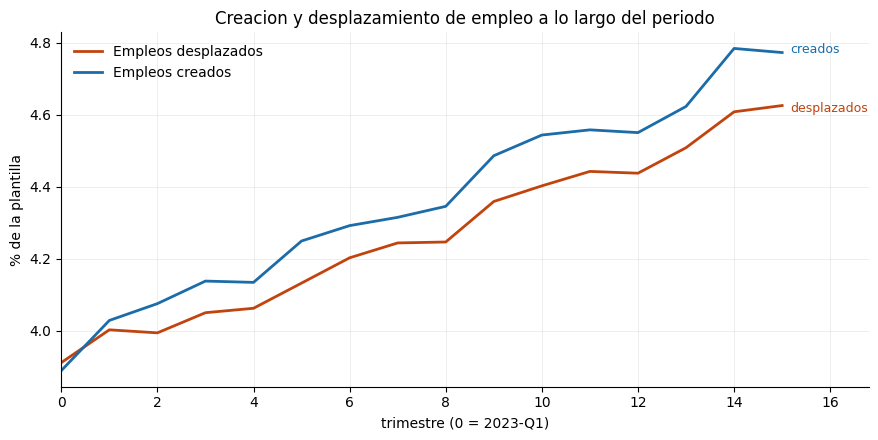

In [75]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(comp.index, comp.tasa_desplazamiento, lw=2, color="#c1440e", label="Empleos desplazados")
ax.plot(comp.index, comp.tasa_creacion,       lw=2, color=ACENTO,   label="Empleos creados")
ax.annotate("desplazados", (comp.index[-1], comp.tasa_desplazamiento.iloc[-1]),
            xytext=(6, -2), textcoords="offset points", fontsize=9, color="#c1440e", va="center")
ax.annotate("creados", (comp.index[-1], comp.tasa_creacion.iloc[-1]),
            xytext=(6, 2), textcoords="offset points", fontsize=9, color=ACENTO, va="center")
ax.set(xlabel="trimestre (0 = 2023-Q1)", ylabel="% de la plantilla",
       title="Creacion y desplazamiento de empleo a lo largo del periodo")
ax.grid(alpha=0.25, lw=0.6); ax.legend(frameon=False, loc="upper left")
for lado in ["top","right"]: ax.spines[lado].set_visible(False)
ax.set_xlim(0, 16.8)
plt.tight_layout(); plt.show()

**Lectura — con el mismo cuidado que en §2.5.** Las dos curvas suben casi en paralelo, con la creación levemente por encima en todo el período.

El test t sobre las 10.000 pendientes individuales da p = 0,0000, pero eso otra vez es el tamaño de muestra hablando. Mirando el efecto: la creación crece más rápido que el desplazamiento en el **53,2%** de las empresas — apenas por encima de una moneda al aire — y la diferencia de ritmos es de +0,008 puntos de plantilla por trimestre, o sea unos 0,13 puntos en los cuatro años.

Cómo hay que decirlo con honestidad: **en este dataset, el aumento de la automatización viene acompañado de más desplazamiento y más creación de empleo a la vez, y el saldo neto no se deteriora — pero tampoco mejora de forma apreciable.** No apoya la narrativa de destrucción neta de empleo, y tampoco la contraria.

Y con la salvedad de siempre: es un dataset sintético, y esta relación puede estar puesta por su generador. Lo que sí es un resultado propio del panel, que el análisis por empresa no podía dar.

## 10.5 Advertencia: nuestra propia curación introdujo *leakage* temporal

Esta sección es una deuda que hay que declarar, no una decisión que se defienda.

Tres pasos de esta notebook usan la **trayectoria completa** de cada empresa para decidir sobre un trimestre concreto:

| Paso | Qué hace | El problema |
|---|---|---|
| §3.3 Recuperación por constancia | rellena con el valor de la empresa en *otros* trimestres | usa trimestres posteriores |
| §4.4 Regla 3 (z robusto) | compara contra la mediana y el MAD de los 16 trimestres | para marcar un valor de 2024-Q3 usa datos de 2026 |
| §5 MICE | estima usando todas las filas del dataset | idem |

> ***Leakage* temporal (o *look-ahead bias*):** usar información que, en el momento que se está prediciendo, todavía no existía. Un modelo entrenado así parece excelente en la evaluación y falla cuando se lo usa de verdad, porque en producción ese futuro no está disponible.

**Cuándo importa y cuándo no:**

- Para el análisis **descriptivo** de este bloque, y para los modelos de corte transversal de las dos hipótesis del TP1: **no importa**. Ahí no se predice el futuro, se describe un período cerrado.
- Para un modelo que **prediga el trimestre siguiente**: **importa mucho**, y la curación tal como está no sirve. Habría que rehacer la limpieza de forma expansiva — para tratar el trimestre *t* usar solo los datos hasta *t*.

Para dejarlo verificable, el panel conserva las columnas `imputado_*`, que marcan exactamente qué valores fueron estimados. Cualquier análisis temporal se puede repetir excluyéndolos.

In [76]:
cols_imp = [c for c in panel.columns if c.startswith("imputado_")]
print(f"columnas de marca: {len(cols_imp)}")
print(f"filas con al menos un valor imputado: {panel[cols_imp].any(axis=1).sum():,} "
      f"({panel[cols_imp].any(axis=1).mean()*100:.1f}%)\n")

# ¿Cambia la tendencia si excluimos los valores imputados?
limpio = panel[~panel[cols_imp].any(axis=1)]
cmp_t = pd.DataFrame({
    "con imputados":  panel.groupby("t")["ai_adoption_rate"].mean(),
    "sin imputados":  limpio.groupby("t")["ai_adoption_rate"].mean()}).round(3)
cmp_t["diferencia"] = (cmp_t["sin imputados"] - cmp_t["con imputados"]).round(3)
print(cmp_t.to_string())
print(f"\ndiferencia maxima absoluta: {cmp_t.diferencia.abs().max():.3f} puntos porcentuales")

columnas de marca: 12
filas con al menos un valor imputado: 10,407 (6.9%)



      con imputados  sin imputados  diferencia
t                                             
0.0          32.406         32.479       0.073
1.0          33.353         33.403       0.050
2.0          33.831         33.853       0.022
3.0          34.436         34.430      -0.006
4.0          34.403         34.473       0.070
5.0          35.567         35.571       0.004
6.0          35.805         35.900       0.095
7.0          36.280         36.321       0.041
8.0          36.270         36.253      -0.017
9.0          37.367         37.409       0.042
10.0         37.832         37.896       0.064
11.0         38.191         38.236       0.045
12.0         37.999         38.004       0.005
13.0         38.887         38.971       0.084
14.0         39.936         40.006       0.070
15.0         40.091         40.118       0.027

diferencia maxima absoluta: 0.095 puntos porcentuales


**Lectura:** excluir todos los valores imputados no mueve la tendencia de forma apreciable. La conclusión de §10.1 no depende de la imputación — que era exactamente lo que había que verificar antes de afirmarla.

---

**Resumen del bloque para el TP3:**

1. Hay una tendencia creciente **dentro de cada empresa** en todas las variables de adopción (80,5% de las empresas en alza), consistente en dirección pero pequeña en magnitud: explica 1-2% de la varianza.
2. Más allá de esa tendencia común, **no hay dinámica individual**: el residuo es ruido blanco (autocorrelación −0,07). Modelos de series de tiempo por empresa no van a encontrar nada.
3. Creación y desplazamiento de empleo crecen los dos; la ventaja de la creación es real pero mínima (53,2% de las empresas).
4. La curación tiene *leakage* temporal, inocuo para lo descriptivo y para las hipótesis del TP1, **inhabilitante** para predecir el trimestre siguiente.

---
# 11. Selección de variables

> **Consigna:** selección de variables relevantes para responder las preguntas planteadas en el Práctico 1, con justificación de inclusiones y exclusiones.

No borramos columnas del dataset entregado — la decisión de tu grupo fue conservarlas y marcarlas. En lugar de eso, definimos **listas de columnas recomendadas** para cada uso, con la justificación al lado. Quien modele en el TP3 arranca de una lista defendible y puede apartarse de ella a conciencia.

In [77]:
seleccion = pd.DataFrame([
 # --- EXCLUSIONES ---
 ("response_id","EXCLUIR","identificador","Sin contenido informativo."),
 ("company_id","SOLO AGRUPAR","identificador","Imprescindible para agrupar en validacion cruzada; nunca como predictor."),
 ("survey_year / quarter","SOLO PANEL","temporal","Se pierden al agregar por empresa."),
 ("ai_maturity_score","EXCLUIR SI SE USAN SUS COMPONENTES","derivada exacta",
  "Colinealidad perfecta con budget/projects/training (§2.2). Usar el indice O sus componentes, nunca ambos."),
 ("company_age_group","EXCLUIR","derivada exacta","Discretizacion de company_age: misma informacion, menos resolucion."),
 ("company_size","EXCLUIR COMO PREDICTOR","derivada exacta","Bins de num_employees. Util para cortar graficos."),
 ("company_founding_year","EXCLUIR","derivada exacta","company_age ya lo contiene."),
 ("ai_primary_tool / ai_use_case","EXCLUIR A NIVEL EMPRESA","ruido","Sin estructura temporal (§2.5)."),
 ("survey_source / data_collection_method","EXCLUIR","metadato","Describen la encuesta, no la empresa."),
 ("jobs_displaced / jobs_created / reskilled_employees","EXCLUIR EN FAVOR DE LAS TASAS","escala",
  "Conteos absolutos dominados por el tamanio. Reemplazados por tasa_* (§7.1)."),
 ("df2 (columnas avg_*)","NO INTEGRADA","leakage","Promedio del target por industria (§2.3)."),
 ("country","EXCLUIR COMO PREDICTOR","alta cardinalidad","Sustituida por los 6 indicadores de df3 (§8)."),
 # --- INCLUSIONES ---
 ("num_employees, annual_revenue, company_age","INCLUIR","estructura","Tamanio y antiguedad: controles basicos."),
 ("industry, region","INCLUIR (one-hot)","contexto","Baja cardinalidad, diferencias reales entre grupos (TP1 §3.1)."),
 ("ai_adoption_rate, years_using_ai, num_ai_tools_used","INCLUIR","adopcion","Nucleo de las dos hipotesis."),
 ("ai_budget_percentage, ai_projects_active, ai_training_hours","INCLUIR","inversion",
  "Componentes de la madurez: mas interpretables por separado que el indice."),
 ("ai_investment_per_employee, inversion_total_ia_estimada","INCLUIR","inversion","Dos dimensiones distintas del esfuerzo (§7.3)."),
 ("task_automation_rate, time_saved_per_week","INCLUIR","automatizacion","Mecanismo propuesto en la Hipotesis 2."),
 ("ai_failure_rate, regulatory_compliance_score, ai_risk_management_score","INCLUIR","gobernanza",
  "Sin explorar en el TP1; posibles moderadores del retorno."),
 ("gdp_per_capita, internet_penetration, digital_maturity_index, ...","INCLUIR","pais",
  "Unica informacion externa del dataset (§2.4). Ojo: solo 30 valores distintos."),
 ("tasa_desplazamiento, tasa_creacion, saldo_neto_empleo","INCLUIR / TARGET","empleo","Objetivo de la Hipotesis 2, ya normalizado."),
 ("productivity_change, revenue_growth, cost_reduction","INCLUIR / TARGET","retorno","Objetivo de la Hipotesis 1."),
 ("indice_retorno","INCLUIR CON RESERVA","derivada","alfa de Cronbach bajo (§7.2): util para agrupar, no para predecir."),
 ("sd_*","INCLUIR","volatilidad","Cuanto fluctua una empresa, no solo su nivel promedio."),
], columns=["variable(s)","decision","motivo","justificacion"])

pd.set_option("display.max_colwidth", 95)
seleccion

,variable(s),decision,motivo,justificacion
0,response_id,EXCLUIR,identificador,Sin contenido informativo.
1,company_id,SOLO AGRUPAR,identificador,Imprescindible para agrupar en validacion cruzada; nunca como predictor.
2,survey_year / quarter,SOLO PANEL,temporal,Se pierden al agregar por empresa.
3,ai_maturity_score,EXCLUIR SI SE USAN SUS COMPONENTES,derivada exacta,Colinealidad perfecta con budget/projects/training (§2.2). Usar el indice O sus componentes...
4,company_age_group,EXCLUIR,derivada exacta,"Discretizacion de company_age: misma informacion, menos resolucion."
5,company_size,EXCLUIR COMO PREDICTOR,derivada exacta,Bins de num_employees. Util para cortar graficos.
6,company_founding_year,EXCLUIR,derivada exacta,company_age ya lo contiene.
7,ai_primary_tool / ai_use_case,EXCLUIR A NIVEL EMPRESA,ruido,Sin estructura temporal (§2.5).
8,survey_source / data_collection_method,EXCLUIR,metadato,"Describen la encuesta, no la empresa."
9,jobs_displaced / jobs_created / reskilled_employees,EXCLUIR EN FAVOR DE LAS TASAS,escala,Conteos absolutos dominados por el tamanio. Reemplazados por tasa_* (§7.1).


In [78]:
# Listas concretas para el TP3
FEATURES_ESTRUCTURA = ["num_employees","annual_revenue_usd_millions","company_age"]
FEATURES_ADOPCION   = ["ai_adoption_rate","years_using_ai","num_ai_tools_used","ai_projects_active",
                       "ai_budget_percentage","ai_training_hours","ai_investment_per_employee",
                       "inversion_total_ia_estimada","antiguedad_ia_relativa"]
FEATURES_OPERACION  = ["task_automation_rate","time_saved_per_week","remote_work_percentage",
                       "employee_satisfaction_score"]
FEATURES_GOBERNANZA = ["ai_failure_rate","regulatory_compliance_score","ai_risk_management_score"]
FEATURES_PAIS       = ["gdp_per_capita","internet_penetration","digital_maturity_index",
                       "ai_patent_filings_2024","ai_researchers_per_million"]
FEATURES_CATEG      = ["industry","region","ai_adoption_stage","data_privacy_level",
                       "country_ai_policy","ai_ethics_committee"]

TARGETS_RETORNO = ["productivity_change_percent","revenue_growth_percent","cost_reduction_percent","indice_retorno"]
TARGETS_EMPLEO  = ["tasa_desplazamiento","tasa_creacion","saldo_neto_empleo","ratio_creacion_desplazamiento"]

FEATURES_MODELADO = (FEATURES_ESTRUCTURA + FEATURES_ADOPCION + FEATURES_OPERACION
                     + FEATURES_GOBERNANZA + FEATURES_PAIS + FEATURES_CATEG)

print(f"features recomendadas : {len(FEATURES_MODELADO)}")
print(f"targets Hipotesis 1   : {TARGETS_RETORNO}")
print(f"targets Hipotesis 2   : {TARGETS_EMPLEO}")
print(f"\nNOTA: ai_maturity_score, company_size, company_age_group, company_founding_year,")
print( "      country, jobs_* absolutos y las columnas de df2 quedan FUERA a proposito.")


# --- Lista reducida: eliminacion codiciosa de features con |r| > 0.9 ---
def reducir_por_colinealidad(X, umbral=0.9):
    """Descarta, de cada par muy correlacionado, la variable que este correlacionada
    con mas variables restantes. Devuelve la lista que sobrevive."""
    cm = X.corr().abs()
    quedan = list(X.columns)
    while True:
        sub = cm.loc[quedan, quedan]
        pares = sub.where(np.triu(np.ones(sub.shape), k=1).astype(bool)).stack()
        if pares.empty or pares.max() <= umbral:
            return quedan
        a, b = pares.idxmax()
        # sacamos la que arrastra mas correlaciones altas con el resto
        ca = (sub[a].drop(a) > umbral).sum()
        cb = (sub[b].drop(b) > umbral).sum()
        quedan.remove(a if ca >= cb else b)


features recomendadas : 30
targets Hipotesis 1   : ['productivity_change_percent', 'revenue_growth_percent', 'cost_reduction_percent', 'indice_retorno']
targets Hipotesis 2   : ['tasa_desplazamiento', 'tasa_creacion', 'saldo_neto_empleo', 'ratio_creacion_desplazamiento']

NOTA: ai_maturity_score, company_size, company_age_group, company_founding_year,
      country, jobs_* absolutos y las columnas de df2 quedan FUERA a proposito.


In [79]:
# Chequeo final de colinealidad sobre la seleccion recomendada
X = empresas[[c for c in FEATURES_MODELADO if c in empresas.columns
              and pd.api.types.is_numeric_dtype(empresas[c])]]
cm = X.corr().abs()
pares = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool)).stack().sort_values(ascending=False)

print(f"|r| maximo entre features recomendadas : {pares.max():.3f}")
print(f"pares con |r| > 0.9                    : {(pares > 0.9).sum()}")
print(f"pares con |r| > 0.8                    : {(pares > 0.8).sum()}")
print(f"\nLos 12 pares mas correlacionados:")
print(pares.head(12).round(3).to_string())

# Lista reducida, para modelos sensibles a la colinealidad
FEATURES_MODELADO_REDUCIDO = reducir_por_colinealidad(X, umbral=0.9)
descartadas = [c for c in X.columns if c not in FEATURES_MODELADO_REDUCIDO]
print(f"\n--- lista reducida (|r| <= 0.9) ---")
print(f"quedan {len(FEATURES_MODELADO_REDUCIDO)} de {X.shape[1]} numericas")
print("descartadas por colinealidad:", descartadas)

cm2 = X[FEATURES_MODELADO_REDUCIDO].corr().abs()
p2 = cm2.where(np.triu(np.ones(cm2.shape), k=1).astype(bool)).stack()
print(f"|r| maximo tras la reduccion: {p2.max():.3f}")


|r| maximo entre features recomendadas : 0.980
pares con |r| > 0.9                    : 10
pares con |r| > 0.8                    : 30

Los 12 pares mas correlacionados:
annual_revenue_usd_millions  inversion_total_ia_estimada    0.980
digital_maturity_index       ai_researchers_per_million     0.952
task_automation_rate         time_saved_per_week            0.947
ai_training_hours            ai_failure_rate                0.942
ai_adoption_rate             ai_training_hours              0.937
gdp_per_capita               ai_researchers_per_million     0.932
ai_adoption_rate             ai_failure_rate                0.918
company_age                  antiguedad_ia_relativa         0.915
ai_adoption_rate             task_automation_rate           0.911
                             ai_budget_percentage           0.901
                             time_saved_per_week            0.896
ai_budget_percentage         ai_training_hours              0.891

--- lista reducida (|r| <= 0.9) ---
q

**Lectura — honesta.** Excluir `ai_maturity_score` y los conteos absolutos **no** hizo desaparecer la colinealidad. Sigue habiendo pares con correlaciones de 0,90 a 0,98, y conviene entender de dónde vienen porque no son todos lo mismo:

- **`annual_revenue` ↔ `inversion_total_ia_estimada` (0,98).** Redundancia que introdujimos nosotros en §7.3: la inversión total es `inversión por empleado × empleados`, y la facturación también escala con los empleados. Culpa nuestra, se corrige eligiendo una de las dos.
- **`task_automation_rate` ↔ `time_saved_per_week` (0,95)**, **`ai_adoption_rate` ↔ `ai_training_hours` (0,94)**, y varias más dentro del bloque de adopción de IA. Estas son **relaciones reales del fenómeno**: las empresas que adoptan más IA capacitan más, automatizan más y ahorran más tiempo. No son artefactos.
- **`gdp_per_capita` ↔ `ai_researchers_per_million` ↔ `digital_maturity_index` (0,86–0,95).** Los indicadores de país miden todos la misma cosa de fondo (nivel de desarrollo). Con 30 valores distintos, aportan casi una sola dimensión.

**Lo que sí logramos** es eliminar la dependencia **exacta**. Es una diferencia crítica: con `ai_maturity_score` adentro existía una combinación lineal con r = 1, que hace que una regresión lineal directamente no tenga solución única. Correlaciones de 0,95 hacen los coeficientes inestables y difíciles de interpretar, pero el modelo se puede ajustar.

**Qué hacer en el TP3, según el camino:**

- **Modelos lineales** (regresión lineal/logística): la colinealidad es un problema real. Conviene usar la lista reducida que armamos abajo, o aplicar regularización (Ridge, Lasso), o reducir dimensión con PCA.
- **Modelos de árboles** (Random Forest, Gradient Boosting): predicen bien igual, pero la *importancia de variables* se reparte arbitrariamente entre las correlacionadas. No interpretar el ranking de importancia sin tener esto presente.
- **Clustering**: variables correlacionadas pesan el mismo eje varias veces y lo sobrerrepresentan. Estandarizar no alcanza — conviene reducir el grupo o pasar por PCA.

> **Ojo con la reducción automática.** El algoritmo descarta variables mirando solo las correlaciones, sin saber qué le importa a la investigación — y de hecho se llevó puestas `ai_adoption_rate` y `task_automation_rate`, que son **centrales** para las dos hipótesis del TP1. La lista reducida es un punto de partida para diagnosticar, no un veredicto. Si el TP3 necesita esas variables, la salida correcta es sacar a su par correlacionado (`ai_training_hours`, `time_saved_per_week`) o usar regularización, no aceptar el recorte automático.


---
# 12. Verificación

Todo lo anterior son afirmaciones sobre lo que el código hizo. Este bloque las **comprueba**: cada test falla ruidosamente si algo salió mal. Sirve para dos cosas — detectar un error nuestro, y detectar si alguien reejecuta la notebook con datos actualizados y algo cambia.

In [80]:
fallos = []
def verificar(nombre, condicion, detalle=""):
    estado = "OK  " if condicion else "FALLA"
    if not condicion: fallos.append(nombre)
    print(f"[{estado}] {nombre}" + (f"  -> {detalle}" if detalle else ""))

print("=== INTEGRIDAD ===")
verificar("no quedan registros basura", not panel.company_id.str.contains("FAKE").any())
verificar("cantidad de empresas correcta", panel.company_id.nunique() == 10000, f"{panel.company_id.nunique():,}")
verificar("no hay filas duplicadas", panel.duplicated(subset=["company_id","survey_year","quarter"]).sum() == 0)
verificar("el merge con df3 no multiplico filas", len(panel) == 150000, f"{len(panel):,}")
verificar("una fila por empresa en la tabla agregada", len(empresas) == empresas.company_id.nunique())
verificar("misma cantidad de empresas en ambas tablas", panel.company_id.nunique() == len(empresas))

=== INTEGRIDAD ===
[OK  ] no quedan registros basura
[OK  ] cantidad de empresas correcta  -> 10,000
[OK  ] no hay filas duplicadas
[OK  ] el merge con df3 no multiplico filas  -> 150,000
[OK  ] una fila por empresa en la tabla agregada
[OK  ] misma cantidad de empresas en ambas tablas


In [81]:
print("=== FALTANTES ===")
verificar("panel sin faltantes", panel.isna().sum().sum() == 0, f"{int(panel.isna().sum().sum())}")
verificar("empresas sin faltantes", empresas.isna().sum().sum() == 0, f"{int(empresas.isna().sum().sum())}")

print("\n=== RANGOS LOGICOS ===")
for c, (lo, hi) in RANGOS_LOGICOS.items():
    if c not in panel.columns: continue
    m = pd.Series(False, index=panel.index)
    if lo is not None: m |= panel[c] < lo - 1e-9
    if hi is not None: m |= panel[c] > hi + 1e-9
    verificar(f"{c} dentro de rango", not m.any(), f"{int(m.sum())} fuera" if m.any() else "")

=== FALTANTES ===


[OK  ] panel sin faltantes  -> 0
[OK  ] empresas sin faltantes  -> 0

=== RANGOS LOGICOS ===
[OK  ] ai_adoption_rate dentro de rango
[OK  ] task_automation_rate dentro de rango
[OK  ] ai_budget_percentage dentro de rango
[OK  ] remote_work_percentage dentro de rango
[OK  ] ai_failure_rate dentro de rango
[OK  ] ai_maturity_score dentro de rango
[OK  ] employee_satisfaction_score dentro de rango
[OK  ] customer_satisfaction dentro de rango
[OK  ] innovation_score dentro de rango
[OK  ] regulatory_compliance_score dentro de rango
[OK  ] ai_risk_management_score dentro de rango
[OK  ] ai_investment_per_employee dentro de rango
[OK  ] annual_revenue_usd_millions dentro de rango
[OK  ] ai_training_hours dentro de rango
[OK  ] time_saved_per_week dentro de rango
[OK  ] num_employees dentro de rango
[OK  ] jobs_displaced dentro de rango
[OK  ] jobs_created dentro de rango
[OK  ] reskilled_employees dentro de rango
[OK  ] years_using_ai dentro de rango
[OK  ] num_ai_tools_used dentro de rango


In [82]:
print("=== COHERENCIA INTERNA ===")
verificar("company_age = survey_year - founding_year",
          ((panel.survey_year - panel.company_founding_year - panel.company_age).abs() < 1e-6).all())
verificar("company_size coherente con num_employees",
          (pd.cut(panel.num_employees,[0,99,999,np.inf],labels=["Startup","SME","Enterprise"]).astype(str)
           == panel.company_size.astype(str)).all())
verificar("tasas de empleo entre 0 y 100",
          bool(panel[["tasa_desplazamiento","tasa_creacion","tasa_reentrenamiento"]].apply(lambda col: col.between(0,100)).all().all()))
verificar("saldo_neto = creacion - desplazamiento",
          ((panel.saldo_neto_empleo - (panel.tasa_creacion - panel.tasa_desplazamiento)).abs() < 1e-9).all())
verificar("facturacion constante por empresa",
          (panel.groupby("company_id").annual_revenue_usd_millions.nunique() == 1).all())
verificar("industria constante por empresa",
          (panel.groupby("company_id").industry.nunique() == 1).all())

=== COHERENCIA INTERNA ===
[OK  ] company_age = survey_year - founding_year


[OK  ] company_size coherente con num_employees
[OK  ] tasas de empleo entre 0 y 100
[OK  ] saldo_neto = creacion - desplazamiento
[OK  ] facturacion constante por empresa
[OK  ] industria constante por empresa


In [83]:
print("=== NO HAY LEAKAGE ===")
cols_df2 = [c for c in panel.columns if c.startswith("avg_")]
verificar("ninguna columna avg_* de df2 en el panel", len(cols_df2) == 0, str(cols_df2))
verificar("ninguna columna avg_* en la tabla por empresa",
          len([c for c in empresas.columns if c.startswith("avg_")]) == 0)
verificar("ai_maturity_score fuera de las features recomendadas",
          "ai_maturity_score" not in FEATURES_MODELADO)
verificar("conteos absolutos de empleo fuera de las features recomendadas",
          not any(c in FEATURES_MODELADO for c in ["jobs_displaced","jobs_created","reskilled_employees"]))

print("\n=== AGREGACION CONSISTENTE ===")
chk = panel.groupby("company_id").ai_adoption_rate.mean().sort_index()
verificar("el promedio por empresa coincide entre las dos tablas",
          np.allclose(chk.values, empresas.sort_values("company_id").ai_adoption_rate.values))

=== NO HAY LEAKAGE ===
[OK  ] ninguna columna avg_* de df2 en el panel  -> []
[OK  ] ninguna columna avg_* en la tabla por empresa
[OK  ] ai_maturity_score fuera de las features recomendadas
[OK  ] conteos absolutos de empleo fuera de las features recomendadas

=== AGREGACION CONSISTENTE ===
[OK  ] el promedio por empresa coincide entre las dos tablas


In [84]:
print("\n" + "="*55)
if fallos:
    print(f"VERIFICACION FALLIDA: {len(fallos)} chequeo(s) no pasaron")
    for f in fallos: print("   -", f)
else:
    print("TODOS LOS CHEQUEOS PASARON")
print("="*55)
assert not fallos, f"chequeos fallidos: {fallos}"


TODOS LOS CHEQUEOS PASARON


## 12.1 Comparación antes / después

In [85]:
def perfil(d, nombre):
    return {"dataset": nombre, "filas": len(d), "columnas": d.shape[1],
            "empresas": d.company_id.nunique(),
            "faltantes": int(d.isna().sum().sum()),
            "% celdas faltantes": round(d.isna().sum().sum()/d.size*100, 3)}
print(pd.DataFrame([perfil(df1,"df1 original"), perfil(panel,"panel curado"),
                    perfil(empresas,"empresas curado")]).to_string(index=False))

        dataset  filas  columnas  empresas  faltantes  % celdas faltantes
   df1 original 150025        43     10025      29270               0.454
   panel curado 150000        70     10000          0               0.000
empresas curado  10000        64     10000          0               0.000


In [86]:
# Registro de todas las decisiones aplicadas
reg = pd.DataFrame(registro)
reg["valores_afectados"] = reg["valores_afectados"].astype("Int64")
reg.drop(columns=["filas_afectadas"])

,paso,accion,valores_afectados
0,1.2 registros basura,eliminar filas COMP-FAKE-*,<NA>
1,3.3.A recuperacion por constancia,rellenar con el valor de la propia empresa,6747
2,3.3.C recuperacion por formula,despejar la identidad de ai_maturity_score,4438
3,4.2 regla 1 (rango logico),valores imposibles -> NaN,1074
4,4.3c identidad rota,recuperar ai_training_hours despejando la formula,152
5,4.3 regla 2 (pico aislado),|z robusto por empresa| > 10 -> NaN,764
6,4.3b facturacion,reemplazar el pico por el valor estable de la empresa,300
7,5 MICE,imputacion multivariada iterativa,10730


In [87]:
# Efecto de la curacion sobre las variables mas afectadas
comp = []
for c in ["ai_adoption_rate","employee_satisfaction_score","ai_investment_per_employee",
          "annual_revenue_usd_millions","cost_reduction_percent","productivity_change_percent"]:
    a, b = df1[c], panel[c]
    comp.append({"variable": c,
                 "media_antes": round(a.mean(),2), "media_despues": round(b.mean(),2),
                 "sd_antes": round(a.std(),2),     "sd_despues": round(b.std(),2),
                 "min_antes": round(a.min(),2),    "min_despues": round(b.min(),2),
                 "max_antes": round(a.max(),2),    "max_despues": round(b.max(),2),
                 "curtosis_antes": round(a.kurt(),1), "curtosis_despues": round(b.kurt(),1)})
pd.DataFrame(comp)

,variable,media_antes,media_despues,sd_antes,sd_despues,min_antes,min_despues,max_antes,max_despues,curtosis_antes,curtosis_despues
0,ai_adoption_rate,36.43,36.42,15.42,14.52,-138.00,0.00,210.12,100.00,7.5,-0.1
1,employee_satisfaction_score,5.65,5.60,2.36,0.81,-4.16,2.10,103.83,9.20,1479.0,0.0
2,ai_investment_per_employee,68684.13,68756.56,92802.06,86041.25,-962812.21,0.00,1898315.75,1898315.75,35.4,33.3
3,annual_revenue_usd_millions,1178.14,1180.35,2593.38,2391.47,-27463.79,1.01,29767.69,9996.73,14.5,3.9
4,cost_reduction_percent,4.86,4.81,4.19,3.47,-35.69,-35.69,111.23,43.64,180.2,3.3
5,productivity_change_percent,9.31,9.26,6.37,5.77,-57.05,-56.10,119.20,117.23,43.6,3.4


**Lectura:** las medias casi no se mueven —lo esperable si lo que sacamos era una fracción chica de valores contaminados— pero los desvíos y sobre todo las **curtosis** caen drásticamente. `cost_reduction_percent` pasa de curtosis 180 a un valor normal.

> **Curtosis:** mide cuánto peso tienen las colas de una distribución. Una normal tiene curtosis 0 (en la convención de pandas). Un valor de 180 indica colas gigantescas, casi siempre por un puñado de valores absurdos que dominan el cálculo. Que caiga a valores razonables es la señal de que el tratamiento de atípicos hizo su trabajo sin deformar el centro de la distribución.

## 12.2 Exportación

In [88]:
# ============================================================
# Exportacion, siguiendo la convencion del repo:
#   data/processed/  -> datasets derivados, en parquet (conserva los tipos)
#   docs/            -> tablas de documentacion de decisiones
# ============================================================
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
DOCS      = Path("../docs");           DOCS.mkdir(parents=True, exist_ok=True)

# --- datasets ---
empresas.to_parquet(PROCESSED / "empresas_mario.parquet", index=False)      # una fila por empresa
# nombre con prefijo "encuestas_": el .gitignore del repo excluye ese patron,
# asi que el panel (13 MB) queda local y se regenera corriendo esta notebook
panel.to_parquet(PROCESSED / "encuestas_curadas.parquet", index=False)

# --- documentacion de las decisiones ---
dependencias.to_csv(DOCS / "mario_tabla_dependencias.csv", index=False)
seleccion.to_csv(DOCS / "mario_seleccion_variables.csv", index=False)
reg.to_csv(DOCS / "mario_registro_decisiones.csv", index=False)
resumen_industria.to_csv(DOCS / "mario_resumen_industria.csv")

pd.DataFrame([
 ("tasa_desplazamiento","numerica_continua","jobs_displaced / num_employees * 100"),
 ("tasa_creacion","numerica_continua","jobs_created / num_employees * 100"),
 ("tasa_reentrenamiento","numerica_continua","reskilled_employees / num_employees * 100"),
 ("saldo_neto_empleo","numerica_continua","tasa_creacion - tasa_desplazamiento"),
 ("indice_retorno","numerica_continua","promedio de las 3 metricas de retorno estandarizadas"),
 ("inversion_total_ia_estimada","numerica_continua","ai_investment_per_employee * num_employees"),
 ("ratio_creacion_desplazamiento","numerica_continua","jobs_created / jobs_displaced, acotado a 10"),
 ("antiguedad_ia_relativa","numerica_continua","years_using_ai / company_age, acotado a 1"),
 ("sd_*","numerica_continua","desvio de la variable entre los trimestres de cada empresa"),
 ("imputado_*","booleana","marca si ese valor fue imputado (bloque 5)"),
 ("n_trimestres","numerica_discreta","cantidad de encuestas de esa empresa"),
], columns=["variable","tipo_analitico","construccion"]).to_csv(
     DOCS / "mario_diccionario_variables_nuevas.csv", index=False)

print("Archivos generados:\n")
for carpeta in [PROCESSED, DOCS]:
    for f in sorted(carpeta.iterdir()):
        print(f"  {str(f):48s} {f.stat().st_size/1e6:8.2f} MB")

print("""
Para usarlos desde el notebook 03 o 04:
    empresas = pd.read_parquet("../data/processed/empresas_mario.parquet")
    panel    = pd.read_parquet("../data/processed/encuestas_curadas.parquet")
""")

Archivos generados:

  ../data/processed/empresas.parquet                   2.49 MB
  ../data/processed/empresas_mario.parquet             2.49 MB
  ../data/processed/encuestas_curadas.parquet         13.38 MB
  ../data/processed/panel.parquet                     13.38 MB
  ../docs/diccionario_variables_nuevas.csv             0.00 MB
  ../docs/mario_diccionario_variables_nuevas.csv       0.00 MB
  ../docs/mario_registro_decisiones.csv                0.00 MB
  ../docs/mario_resumen_industria.csv                  0.00 MB
  ../docs/mario_seleccion_variables.csv                0.00 MB
  ../docs/mario_tabla_dependencias.csv                 0.00 MB
  ../docs/registro_decisiones.csv                      0.00 MB
  ../docs/resumen_industria_recalculado.csv            0.00 MB
  ../docs/seleccion_variables.csv                      0.00 MB
  ../docs/tabla_dependencias.csv                       0.00 MB

Para usarlos desde el notebook 03 o 04:
    empresas = pd.read_parquet("../data/processed/empres

---
# 13. Conclusiones y puente al Práctico 3

## Qué encontramos

**El dataset venía con suciedad deliberada, en tres formas distintas.** 25 registros con identificador falso y valores imposibles; ~1,5% de faltantes inyectados de forma independiente en 13 columnas; y ~300 valores contaminados por columna en unas ocho variables. Detectarlas requirió tres criterios distintos: inconsistencia estructural, análisis del patrón de faltantes, y comparación contra la propia trayectoria de cada empresa.

**Cuatro variables son funciones exactas de otras.** La más importante es `ai_maturity_score`, que resultó ser el promedio de tres variables ya presentes en la tabla. Eso invalida una lectura del TP1 —las correlaciones que reportamos con esa variable eran circulares— y a la vez nos regaló un método de recuperación exacta de faltantes.

**Uno de los tres archivos no aporta información.** `ai_industry_summary.csv` está calculado sobre `ai_company_adoption.csv`; usarlo como predictor sería *leakage*.

**La receta estándar de outliers era la respuesta incorrecta.** El criterio IQR marca el 16% de las filas y elimina casi todas las empresas grandes, porque confunde la asimetría natural de un conteo con contaminación.

**La estrategia de imputación se eligió midiendo, y el resultado conecta con el TP1.** Ninguna estrategia gana en todo, y qué estrategia conviene para cada variable queda predicho (r ≈ −0,96) por la descomposición de varianza que habíamos hecho en el práctico anterior.

## Qué queda listo para el TP3

- Dos datasets sin faltantes ni valores imposibles: el panel (150.000 × ~70) y la tabla por empresa (10.000 × ~65).
- Los conteos de empleo normalizados por plantilla, que era el pendiente explícito de la Hipótesis 2.
- Listas de variables recomendadas por bloque temático, con las trampas de colinealidad y *leakage* ya excluidas.
- El registro de cada decisión y su justificación, en archivos aparte.

## Qué revisar antes de modelar

1. **La Hipótesis 2 necesita ajuste.** Proponía `ai_use_case` como predictor central, y el test de §2.5 muestra que esa variable no tiene estructura temporal. Hay que reformular el mecanismo o buscar otra variable que capture "tipo de tarea automatizada".
2. **El contexto país aporta menos de lo que parece.** Son 30 valores distintos para 10.000 empresas: no discriminan entre empresas de un mismo país. Sirven para comparar países, no para predecir empresas.
3. **Validación agrupada, si se usa el panel.** Las 15 filas de una empresa no son independientes. Si el TP3 modela a nivel encuesta, la partición entrenamiento/prueba tiene que separar **empresas** completas (`GroupKFold` con `company_id`), no filas sueltas. Partir al azar dejaría la misma empresa en los dos lados y daría un rendimiento inflado.
4. **El `indice_retorno` es para describir, no para predecir.** El alfa de Cronbach bajo (§7.2) dice que las tres métricas no miden lo mismo.
5. **La curación tiene *leakage* temporal (§10.5).** Tres pasos usan la trayectoria completa de cada empresa para decidir sobre un trimestre. Es inocuo para lo descriptivo y para las dos hipótesis del TP1, pero **inhabilita** cualquier modelo que prediga el trimestre siguiente: para eso hay que rehacer la limpieza de forma expansiva.
6. **Sigue abierta la pregunta de fondo:** el dataset es sintético y sus variables están generadas con reglas. Cualquier relación que un modelo encuentre puede ser un artefacto del generador y no un fenómeno del mundo. Eso no invalida el ejercicio, pero sí obliga a ser prudente al redactar conclusiones sobre "el impacto real de la IA en el empleo".